In [1]:
import copy
import datetime as dt
from datetime import datetime
import importlib  # needed so that we can reload packages
import logging
import os
import pathlib
import sys
import time
import warnings
from typing import Union, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from utils.logger_utils import setup_clean_logger, mute_external_loggers

# SISEPUEDE imports
from sisepuede.manager.sisepuede_examples import SISEPUEDEExamples
from sisepuede.manager.sisepuede_file_structure import SISEPUEDEFileStructure
import sisepuede.core.support_classes as sc
import sisepuede.transformers as trf
import sisepuede.utilities._plotting as spu
import sisepuede.utilities._toolbox as sf
import sisepuede.core.attribute_table as att
import sisepuede.manager.sisepuede_examples as sxl
import sisepuede.manager.sisepuede_file_structure as sfs
import sisepuede.manager.sisepuede_models as sm
import sisepuede.visualization.plots as svp

# --- Runtime configuration ---
warnings.filterwarnings("ignore")

# Set up a clean logger for your notebook
logger = setup_clean_logger("notebook", logging.INFO)
logger.info("Notebook started successfully.")

# Mute logs from sisepuede to avoid duplication
mute_external_loggers(["sisepuede"])


/opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packages/munch/__init__.py:24: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
2025-12-02 17:57:07,627 - INFO - Notebook started successfully.


In [2]:
%load_ext autoreload
%autoreload 2

### Initial Set up

Make sure to edit the config yaml under ssp_modeling/config_files/config.yaml

You can also create a new config yaml



In [3]:
# Set up dir paths

CURR_DIR_PATH = pathlib.Path(os.getcwd())
SSP_MODELING_DIR_PATH = CURR_DIR_PATH.parent
PROJECT_DIR_PATH = SSP_MODELING_DIR_PATH.parent
DATA_DIR_PATH = SSP_MODELING_DIR_PATH.joinpath("input_data")
RUN_OUTPUT_DIR_PATH = SSP_MODELING_DIR_PATH.joinpath("ssp_run_output")
SCENARIO_MAPPING_DIR_PATH = SSP_MODELING_DIR_PATH.joinpath("scenario_mapping")
CONFIG_DIR_PATH = CURR_DIR_PATH.joinpath("config_files")
TRANSFORMATIONS_DIR_PATH = SSP_MODELING_DIR_PATH.joinpath("transformations")
MISC_DIR_PATH = SSP_MODELING_DIR_PATH.joinpath("misc")
STRATEGIES_DEFINITIONS_FILE_PATH = TRANSFORMATIONS_DIR_PATH.joinpath("strategy_definitions.csv")
STRATEGY_MAPPING_FILE_PATH = MISC_DIR_PATH.joinpath("strategy_mapping.yaml")

In [4]:
from ssp_transformations_handler.GeneralUtils import GeneralUtils
from ssp_transformations_handler.TransformationUtils import TransformationYamlProcessor, StrategyCSVHandler

# Initialize general utilities
g_utils = GeneralUtils()

In [5]:
# Load config file, double check your parameters are correct

YAML_FILE_PATH = os.path.join(CONFIG_DIR_PATH, "config.yaml")
config_params = g_utils.read_yaml(YAML_FILE_PATH)

country_name = config_params['country_name']
ssp_input_file_name = config_params['ssp_input_file_name']
ssp_transformation_cw = config_params['ssp_transformation_cw']
energy_model_flag = config_params['energy_model_flag']
set_lndu_reallocation_factor_to_zero_flag = config_params['set_lndu_reallocation_factor_to_zero']
sim_end_year = config_params.get('sim_end_year', 2050)  # Default to 2050 if not specified

# Print config parameters
logger.info(f"Country name: {country_name}")
logger.info(f"SSP input file name: {ssp_input_file_name}")
logger.info(f"SSP transformation CW: {ssp_transformation_cw}")
logger.info(f"Energy model flag: {energy_model_flag}")
logger.info(f"Set lndu reallocation factor to zero flag: {set_lndu_reallocation_factor_to_zero_flag}")
logger.info(f"Simulation end year: {sim_end_year}")

2025-12-02 17:57:07,723 - INFO - Country name: bulgaria
2025-12-02 17:57:07,723 - INFO - SSP input file name: sisepuede_raw_inputs_latest_BGR_nov_12.csv
2025-12-02 17:57:07,723 - INFO - SSP transformation CW: ssp_bulgaria_transformation_nov_27.xlsx
2025-12-02 17:57:07,723 - INFO - Energy model flag: False
2025-12-02 17:57:07,723 - INFO - Set lndu reallocation factor to zero flag: True
2025-12-02 17:57:07,724 - INFO - Simulation end year: 2050


In [6]:
def get_file_structure(
    y0: int = 2015,
    y1: int = sim_end_year,
) -> Tuple[sfs.SISEPUEDEFileStructure, att.AttributeTable]:
    """Get the SISEPUEDE File Structure and update the attribute table
        with new years.
    """
    # setup some SISEPUEDE variables and update time period
    file_struct = sfs.SISEPUEDEFileStructure(
        initialize_directories = False,
    )
 
    # get some keys
    key_time_period = file_struct.model_attributes.dim_time_period
    key_year = file_struct.model_attributes.field_dim_year
 
 
    ##  BUILD THE ATTRIBUTE AND UPDATE
 
    # setup the new attribute table
    years = np.arange(y0, y1 + 1, ).astype(int)
    attribute_time_period = att.AttributeTable(
        pd.DataFrame(
            {
                key_time_period: range(len(years)),
                key_year: years,
            }
        ),
        key_time_period,
    )
 
    # finally, update the ModelAttributes inside the file structure
    (
        file_struct
        .model_attributes
        .update_dimensional_attribute_table(
            attribute_time_period,
        )
    )
 
    # return the tuple
    out = (file_struct, attribute_time_period, )
 
    return out


In [7]:
# Set up SSP objects
INPUT_FILE_PATH = DATA_DIR_PATH.joinpath(ssp_input_file_name)

# model attributes and associated support classes
_EXAMPLES = sxl.SISEPUEDEExamples()
_FILE_STRUCTURE, _ATTRIBUTE_TABLE_TIME_PERIOD = get_file_structure()
matt = _FILE_STRUCTURE.model_attributes
regions = sc.Regions(matt, )
time_periods = sc.TimePeriods(matt, )

In [8]:
# # setup models if necessary
# models = sm.SISEPUEDEModels(
#     matt,
#     allow_electricity_run = True,
#     fp_julia = _FILE_STRUCTURE.dir_jl,
#     fp_nemomod_reference_files = _FILE_STRUCTURE.dir_ref_nemo,
#     initialize_julia = True, 
# )

### Making sure our input file has the correct format and correct columns
We use an example df with the complete fields and correct format to make sure our file is in the right shape

In [9]:
INPUT_FILE_PATH

PosixPath('/Users/tony/Documents/sisepuede_modeling/ssp_bulgaria/ssp_modeling/input_data/sisepuede_raw_inputs_latest_BGR_nov_12.csv')

In [10]:
##  BUILD BASE INPUTS
df_inputs_raw = pd.read_csv(INPUT_FILE_PATH)

# pull example data to fill in gaps
df_example_input = _EXAMPLES("input_data_frame")

In [11]:
# Double checking that our df is in the correct shape (Empty sets should be printed to make sure everything is Ok!)
g_utils.compare_dfs(df_example_input, df_inputs_raw)

Columns in df_example but not in df_input: {'region'}
Columns in df_input but not in df_example: {'iso_alpha_3', 'year'}


In [12]:
# Ensure if time_period field exist
if 'time_period' not in df_inputs_raw.columns:
    logger.info("Adding 'time_period' column to df_inputs_raw")
    df_inputs_raw = df_inputs_raw.rename(columns={'period':'time_period'})
else:
    logger.info("'time_period' column already exists in df_inputs_raw")

2025-12-02 17:57:08,453 - INFO - 'time_period' column already exists in df_inputs_raw


In [13]:
# Fixes differences and makes sure that our df is in the correct format.
# Note: Edit this if you need more changes in your df

df_inputs_raw_complete = g_utils.add_missing_cols(df_example_input, df_inputs_raw.copy())
df_inputs_raw_complete.head()

,year,ef_ippu_tonne_nf3_per_tonne_production_chemicals,ef_ippu_tonne_nf3_per_tonne_production_electronics,ef_ippu_tonne_sf6_per_mmm_gdp_other_product_manufacturing,ef_ippu_tonne_sf6_per_tonne_production_chemicals,ef_ippu_tonne_sf6_per_tonne_production_electronics,ef_ippu_tonne_sf6_per_tonne_production_metals,frac_agrc_bevs_and_spices_cl2_dry,frac_agrc_cereals_cl2_dry,frac_agrc_fibers_cl2_dry,...,nemomod_entc_scalar_availability_factor_pp_geothermal,nemomod_entc_scalar_availability_factor_pp_hydropower,nemomod_entc_scalar_availability_factor_pp_nuclear,nemomod_entc_scalar_availability_factor_pp_ocean,nemomod_entc_scalar_availability_factor_pp_oil,nemomod_entc_scalar_availability_factor_pp_solar,nemomod_entc_scalar_availability_factor_pp_waste_incineration,nemomod_entc_scalar_availability_factor_pp_wind,iso_alpha_3,region
0,2015,0.0,0.0,0.000669,0.0,2.653341e-07,0.0,0.085847,0.085847,0.085847,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,BGR,costa_rica
1,2016,0.0,0.0,0.000696,0.0,2.672084e-07,0.0,0.085847,0.085847,0.085847,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,BGR,costa_rica
2,2017,0.0,0.0,0.000307,0.0,1.171112e-07,0.0,0.085847,0.085847,0.085847,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,BGR,costa_rica
3,2018,0.0,0.0,0.000398,0.0,1.287155e-07,0.0,0.085847,0.085847,0.085847,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,BGR,costa_rica
4,2019,0.0,0.0,0.000389,0.0,1.188816e-07,0.0,0.085847,0.085847,0.085847,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,BGR,costa_rica


In [14]:
# Double checking that our df is in the correct shape (Empty sets should be printed to make sure everything is Ok!)
g_utils.compare_dfs(df_example_input, df_inputs_raw_complete)

Columns in df_example but not in df_input: set()
Columns in df_input but not in df_example: {'iso_alpha_3', 'year'}


In [15]:
# check region field
df_inputs_raw_complete['region'].unique()

array(['costa_rica', nan], dtype=object)

In [16]:
# Set region to country name
df_inputs_raw_complete['region'] = country_name
df_inputs_raw_complete['region'].head()

0    bulgaria
1    bulgaria
2    bulgaria
3    bulgaria
4    bulgaria
Name: region, dtype: object

In [17]:
# filter out years beyond sim_end_year
df_inputs_raw_complete = df_inputs_raw_complete[df_inputs_raw_complete["year"] <= sim_end_year]
df_inputs_raw_complete['year'].unique()

array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025,
       2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036,
       2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047,
       2048, 2049, 2050])

## Update Drivers

### Socioeconomic

In [18]:
new_socio_df = pd.read_excel(DATA_DIR_PATH.joinpath("GDP_and_population projections.xlsx"), sheet_name="new_gdp_and_pop")
new_socio_df

,year,gdp_growth_rate,population
0,2024,0.034000,6918672
1,2025,0.030000,6860349
2,2026,0.029000,6802438
3,2027,0.031000,6744339
4,2028,0.022804,6685753
5,2029,0.020762,6629192
6,2030,0.020772,6574153
7,2031,0.019891,6520799
8,2032,0.019864,6469093
9,2033,0.019715,6419371


In [19]:
pct_change = (new_socio_df["population"].iloc[-1] - new_socio_df["population"].iloc[0]) \
             / new_socio_df["population"].iloc[0]
pct_change

np.float64(-0.15740289465955315)

In [20]:
df_inputs_raw_complete[["year", "gdp_mmm_usd", "population_gnrl_rural", "population_gnrl_urban"]]

,year,gdp_mmm_usd,population_gnrl_rural,population_gnrl_urban
0,2015,143.440000,1.866995e+06,5.310996e+06
1,2016,147.780000,1.829783e+06,5.298039e+06
2,2017,151.830000,1.792408e+06,5.283539e+06
3,2018,155.930000,1.755697e+06,5.269340e+06
4,2019,162.220000,1.719734e+06,5.256027e+06
5,2020,155.780000,1.685936e+06,5.248079e+06
6,2021,167.720000,1.687028e+06,5.347596e+06
7,2022,174.310000,1.655474e+06,5.345491e+06
8,2023,177.527763,1.623920e+06,5.343387e+06
9,2024,182.386697,1.592366e+06,5.341282e+06


In [21]:
import pandas as pd

# -----------------------------
# 1) Merge base inputs with socio projections
# -----------------------------
# df_inputs_raw_complete : original input df (2015–2050) with:
#   - year
#   - gdp_mmm_usd
#   - population_gnrl_rural
#   - population_gnrl_urban
#
# new_socio_df : socio projections (e.g. 2024–2051) with:
#   - year
#   - gdp_growth_rate
#   - population   (total)
# -----------------------------

updated_input_df = df_inputs_raw_complete.merge(new_socio_df, on="year", how="left")
updated_input_df = updated_input_df.sort_values("year").reset_index(drop=True)

# -----------------------------
# 2) Build total population where missing
#    (for historical years: rural + urban)
# -----------------------------
mask_pop_missing = updated_input_df["population"].isna()
updated_input_df.loc[mask_pop_missing, "population"] = (
    updated_input_df.loc[mask_pop_missing, "population_gnrl_rural"]
    + updated_input_df.loc[mask_pop_missing, "population_gnrl_urban"]
)

# -----------------------------
# 3) Compute rural / urban shares from last known year (2023)
# -----------------------------
last_year = 2023
row_2023 = updated_input_df.loc[updated_input_df["year"] == last_year].iloc[0]

total_2023 = row_2023["population_gnrl_rural"] + row_2023["population_gnrl_urban"]
rural_share = row_2023["population_gnrl_rural"] / total_2023
urban_share = row_2023["population_gnrl_urban"] / total_2023  # or 1 - rural_share

# -----------------------------
# 4) Rebuild GDP from 2024 onward using growth rates
# -----------------------------
updated_input_df["gdp_mmm_usd_rebuilt"] = updated_input_df["gdp_mmm_usd"]

start_year = 2024
years = updated_input_df["year"].values

for i in range(len(updated_input_df)):
    year_i = years[i]
    if year_i >= start_year:
        prev_gdp = updated_input_df.loc[i - 1, "gdp_mmm_usd_rebuilt"]
        growth = updated_input_df.loc[i, "gdp_growth_rate"]
        if pd.notna(growth):
            updated_input_df.loc[i, "gdp_mmm_usd_rebuilt"] = prev_gdp * (1 + growth)

# -----------------------------
# 5) Rebuild rural + urban population from 2024 onward
# -----------------------------
# Initialize rebuilt columns as copies of original (for 2015–2023)
updated_input_df["population_gnrl_rural_rebuilt"] = updated_input_df["population_gnrl_rural"]
updated_input_df["population_gnrl_urban_rebuilt"] = updated_input_df["population_gnrl_urban"]

future_mask = updated_input_df["year"] >= start_year

updated_input_df.loc[future_mask, "population_gnrl_rural_rebuilt"] = (
    updated_input_df.loc[future_mask, "population"] * rural_share
)

updated_input_df.loc[future_mask, "population_gnrl_urban_rebuilt"] = (
    updated_input_df.loc[future_mask, "population"] * urban_share
)


In [22]:
updated_input_df[["year", "gdp_mmm_usd","gdp_mmm_usd_rebuilt", "population_gnrl_rural", "population_gnrl_rural_rebuilt", "population_gnrl_urban", "population_gnrl_urban_rebuilt"]]

,year,gdp_mmm_usd,gdp_mmm_usd_rebuilt,population_gnrl_rural,population_gnrl_rural_rebuilt,population_gnrl_urban,population_gnrl_urban_rebuilt
0,2015,143.440000,143.440000,1.866995e+06,1.866995e+06,5.310996e+06,5.310996e+06
1,2016,147.780000,147.780000,1.829783e+06,1.829783e+06,5.298039e+06,5.298039e+06
2,2017,151.830000,151.830000,1.792408e+06,1.792408e+06,5.283539e+06,5.283539e+06
3,2018,155.930000,155.930000,1.755697e+06,1.755697e+06,5.269340e+06,5.269340e+06
4,2019,162.220000,162.220000,1.719734e+06,1.719734e+06,5.256027e+06,5.256027e+06
5,2020,155.780000,155.780000,1.685936e+06,1.685936e+06,5.248079e+06,5.248079e+06
6,2021,167.720000,167.720000,1.687028e+06,1.687028e+06,5.347596e+06,5.347596e+06
7,2022,174.310000,174.310000,1.655474e+06,1.655474e+06,5.345491e+06,5.345491e+06
8,2023,177.527763,177.527763,1.623920e+06,1.623920e+06,5.343387e+06,5.343387e+06
9,2024,182.386697,183.563707,1.592366e+06,1.612585e+06,5.341282e+06,5.306087e+06


In [23]:
updated_input_df["new_pop_check"] = updated_input_df["population_gnrl_rural_rebuilt"] + updated_input_df["population_gnrl_urban_rebuilt"]

In [24]:
updated_input_df[["year", "population_gnrl_rural", "population_gnrl_rural_rebuilt", "population_gnrl_urban", "population_gnrl_urban_rebuilt", "population", "new_pop_check"]].to_csv(DATA_DIR_PATH.joinpath("socio_data_for_edmundo.csv"), index=False)

<Axes: xlabel='year'>

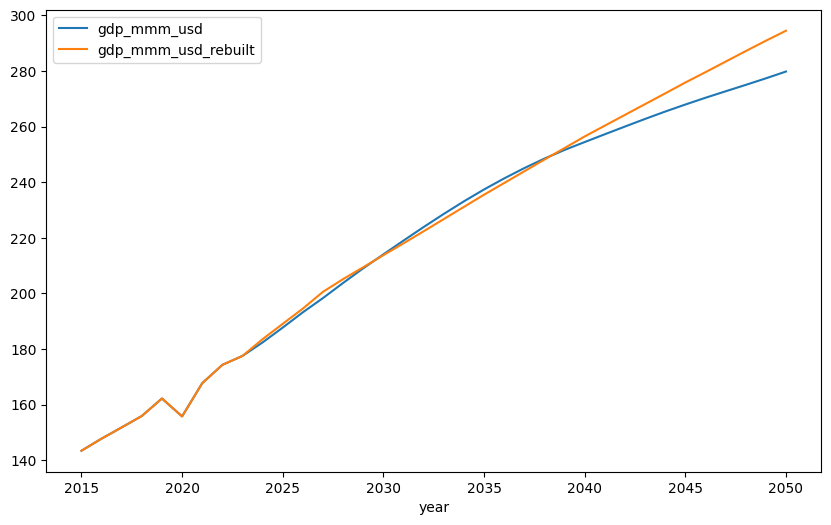

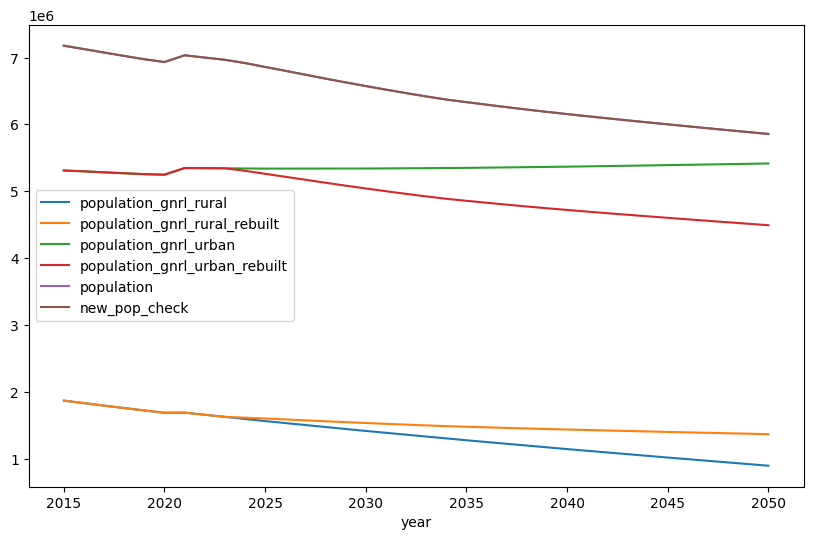

In [25]:
updated_input_df[["year", "gdp_mmm_usd","gdp_mmm_usd_rebuilt"]].plot(x="year", figsize=(10,6))
updated_input_df[["year", "population_gnrl_rural", "population_gnrl_rural_rebuilt", "population_gnrl_urban", "population_gnrl_urban_rebuilt", "population", "new_pop_check"]].plot(x="year", figsize=(10,6))

In [26]:
# -----------------------------------------
# Replace original fields with rebuilt ones
# -----------------------------------------

updated_input_df["gdp_mmm_usd"] = updated_input_df["gdp_mmm_usd_rebuilt"]
updated_input_df["population_gnrl_rural"] = updated_input_df["population_gnrl_rural_rebuilt"]
updated_input_df["population_gnrl_urban"] = updated_input_df["population_gnrl_urban_rebuilt"]

# -----------------------------------------
# Remove helper fields
# -----------------------------------------

cols_to_drop = [
    "gdp_mmm_usd_rebuilt",
    "population_gnrl_rural_rebuilt",
    "population_gnrl_urban_rebuilt",
    "gdp_growth_rate"
]

# Only drop columns that exist (safe)
cols_to_drop = [c for c in cols_to_drop if c in updated_input_df.columns]

updated_input_df = updated_input_df.drop(columns=cols_to_drop)

# -----------------------------------------
# Reset index (optional)
# -----------------------------------------
updated_input_df = updated_input_df.reset_index(drop=True)

In [27]:
pct_change = (updated_input_df["population_gnrl_urban"].iloc[-1] - updated_input_df["population_gnrl_urban"].iloc[0]) \
             / updated_input_df["population_gnrl_urban"].iloc[0]
pct_change

np.float64(-0.154143196566501)

### Crops

**CO2 biomass**

In [28]:
co2_crop_biomass_fields = [col for col in updated_input_df.columns if "ef_agrc_biomass_" in col and "co2" in col]
co2_crop_biomass_fields

['ef_agrc_biomass_bevs_and_spices_tonne_co2_ha',
 'ef_agrc_biomass_fruits_tonne_co2_ha',
 'ef_agrc_biomass_nuts_tonne_co2_ha',
 'ef_agrc_biomass_other_woody_perennial_tonne_co2_ha']

In [29]:
updated_input_df[co2_crop_biomass_fields].head()

,ef_agrc_biomass_bevs_and_spices_tonne_co2_ha,ef_agrc_biomass_fruits_tonne_co2_ha,ef_agrc_biomass_nuts_tonne_co2_ha,ef_agrc_biomass_other_woody_perennial_tonne_co2_ha
0,0.211494,0.149275,0.158703,0.276563
1,0.211494,0.149275,0.158703,0.276563
2,0.211494,0.149275,0.158703,0.276563
3,0.211494,0.149275,0.158703,0.276563
4,0.211494,0.149275,0.158703,0.276563


In [30]:
# Scale up the biomass emission factors by a factor of 3
updated_input_df[co2_crop_biomass_fields] = updated_input_df[co2_crop_biomass_fields] * 9.0
updated_input_df[co2_crop_biomass_fields].head(8)

,ef_agrc_biomass_bevs_and_spices_tonne_co2_ha,ef_agrc_biomass_fruits_tonne_co2_ha,ef_agrc_biomass_nuts_tonne_co2_ha,ef_agrc_biomass_other_woody_perennial_tonne_co2_ha
0,1.903449,1.343477,1.428329,2.48907
1,1.903449,1.343477,1.428329,2.48907
2,1.903449,1.343477,1.428329,2.48907
3,1.903449,1.343477,1.428329,2.48907
4,1.903449,1.343477,1.428329,2.48907
5,1.903449,1.343477,1.428329,2.48907
6,1.903449,1.343477,1.428329,2.48907
7,1.903449,1.343477,1.428329,2.48907


In [31]:
initial_crop_area_fields = matt.get_variable("Initial Cropland Area Proportion")
initial_crop_area_fields.get_from_dataframe(updated_input_df).head(10)

,frac_agrc_initial_area_cropland_bevs_and_spices,frac_agrc_initial_area_cropland_cereals,frac_agrc_initial_area_cropland_fibers,frac_agrc_initial_area_cropland_fruits,frac_agrc_initial_area_cropland_herbs_and_other_perennial_crops,frac_agrc_initial_area_cropland_nuts,frac_agrc_initial_area_cropland_other_annual,frac_agrc_initial_area_cropland_other_woody_perennial,frac_agrc_initial_area_cropland_pulses,frac_agrc_initial_area_cropland_rice,frac_agrc_initial_area_cropland_sugar_cane,frac_agrc_initial_area_cropland_tubers,frac_agrc_initial_area_cropland_vegetables_and_vines
0,0.0,0.354893,0.000853,0.014518,0.007652,0.001435,0.449358,0.0,0.003764,0.002415,0.0,0.002144,0.162968
1,0.0,0.353038,0.001764,0.014158,0.007639,0.001796,0.443979,0.0,0.006600,0.002344,0.0,0.001638,0.167044
2,0.0,0.328843,0.001846,0.013539,0.004728,0.001536,0.451322,0.0,0.016495,0.001996,0.0,0.002449,0.177246
3,0.0,0.598108,0.001045,0.022050,0.000000,0.002671,0.065526,0.0,0.032147,0.003641,0.0,0.004668,0.270143
4,0.0,0.627182,0.001464,0.021290,0.000000,0.002829,0.053720,0.0,0.010689,0.003870,0.0,0.003041,0.275916
5,0.0,0.639643,0.001274,0.020138,0.000000,0.003068,0.043508,0.0,0.008607,0.004043,0.0,0.003258,0.276461
6,0.0,0.632818,0.000818,0.020677,0.000000,0.003554,0.046300,0.0,0.008747,0.003921,0.0,0.003547,0.279618
7,0.0,0.613145,0.000000,0.020564,0.000000,0.003695,0.046824,0.0,0.005735,0.003432,0.0,0.002972,0.303633
8,0.0,0.613145,0.000000,0.020564,0.000000,0.003695,0.046824,0.0,0.005735,0.003432,0.0,0.002972,0.303633
9,0.0,0.613145,0.000000,0.020564,0.000000,0.003695,0.046824,0.0,0.005735,0.003432,0.0,0.002972,0.303633


We need to increase crop are for:

- other_woody_perennial
- fruits
- nuts
- bevs_and_spices

In [32]:
# Update initial crop area fields

new_vals = {
    "frac_agrc_initial_area_cropland_bevs_and_spices": 0.020,
    "frac_agrc_initial_area_cropland_cereals": 0.330,
    "frac_agrc_initial_area_cropland_fibers": 0.002,
    "frac_agrc_initial_area_cropland_fruits": 0.150,
    "frac_agrc_initial_area_cropland_herbs_and_other_perennial_crops": 0.025,
    "frac_agrc_initial_area_cropland_nuts": 0.090,
    "frac_agrc_initial_area_cropland_other_annual": 0.140,
    "frac_agrc_initial_area_cropland_other_woody_perennial": 0.110,
    "frac_agrc_initial_area_cropland_pulses": 0.022,
    "frac_agrc_initial_area_cropland_rice": 0.006,
    "frac_agrc_initial_area_cropland_sugar_cane": 0.000,
    "frac_agrc_initial_area_cropland_tubers": 0.020,
    "frac_agrc_initial_area_cropland_vegetables_and_vines": 0.085,
}




# Update initial crop area fields with fixed fractions across all rows
for col, val in new_vals.items():
    updated_input_df[col] = val

# Quick check
updated_input_df[list(new_vals.keys())].head(10)



,frac_agrc_initial_area_cropland_bevs_and_spices,frac_agrc_initial_area_cropland_cereals,frac_agrc_initial_area_cropland_fibers,frac_agrc_initial_area_cropland_fruits,frac_agrc_initial_area_cropland_herbs_and_other_perennial_crops,frac_agrc_initial_area_cropland_nuts,frac_agrc_initial_area_cropland_other_annual,frac_agrc_initial_area_cropland_other_woody_perennial,frac_agrc_initial_area_cropland_pulses,frac_agrc_initial_area_cropland_rice,frac_agrc_initial_area_cropland_sugar_cane,frac_agrc_initial_area_cropland_tubers,frac_agrc_initial_area_cropland_vegetables_and_vines
0,0.02,0.33,0.002,0.15,0.025,0.09,0.14,0.11,0.022,0.006,0.0,0.02,0.085
1,0.02,0.33,0.002,0.15,0.025,0.09,0.14,0.11,0.022,0.006,0.0,0.02,0.085
2,0.02,0.33,0.002,0.15,0.025,0.09,0.14,0.11,0.022,0.006,0.0,0.02,0.085
3,0.02,0.33,0.002,0.15,0.025,0.09,0.14,0.11,0.022,0.006,0.0,0.02,0.085
4,0.02,0.33,0.002,0.15,0.025,0.09,0.14,0.11,0.022,0.006,0.0,0.02,0.085
5,0.02,0.33,0.002,0.15,0.025,0.09,0.14,0.11,0.022,0.006,0.0,0.02,0.085
6,0.02,0.33,0.002,0.15,0.025,0.09,0.14,0.11,0.022,0.006,0.0,0.02,0.085
7,0.02,0.33,0.002,0.15,0.025,0.09,0.14,0.11,0.022,0.006,0.0,0.02,0.085
8,0.02,0.33,0.002,0.15,0.025,0.09,0.14,0.11,0.022,0.006,0.0,0.02,0.085
9,0.02,0.33,0.002,0.15,0.025,0.09,0.14,0.11,0.022,0.006,0.0,0.02,0.085


In [33]:
# check if they sum to one
updated_input_df[list(new_vals.keys())].sum(axis=1).unique()

array([1.])

In [34]:
crop_yf_fields = matt.get_variable("Crop Yield Factor")
crop_yf_fields.get_from_dataframe(updated_input_df).head(8)

,yf_agrc_bevs_and_spices_tonne_ha,yf_agrc_cereals_tonne_ha,yf_agrc_fibers_tonne_ha,yf_agrc_fruits_tonne_ha,yf_agrc_herbs_and_other_perennial_crops_tonne_ha,yf_agrc_nuts_tonne_ha,yf_agrc_other_annual_tonne_ha,yf_agrc_other_woody_perennial_tonne_ha,yf_agrc_pulses_tonne_ha,yf_agrc_rice_tonne_ha,yf_agrc_sugar_cane_tonne_ha,yf_agrc_tubers_tonne_ha,yf_agrc_vegetables_and_vines_tonne_ha
0,1.664986,4.664457,0.500738,6.487901,1.039938,0.839997,1.062913,0.5,1.966460,5.4540,55.765409,14.9633,2.555236
1,1.664986,4.815067,0.646642,5.774278,1.051730,0.872306,1.204477,0.5,2.296954,5.4032,55.765409,15.1841,2.967399
2,1.664986,5.479701,0.622755,6.085818,1.011737,0.821764,1.196420,0.5,2.479671,5.6089,55.765409,17.7897,2.826425
3,1.664986,5.561910,0.755500,6.425891,1.011737,0.842645,2.481176,0.5,1.299027,5.5200,55.765409,18.5596,3.076353
4,1.664986,5.773301,1.024141,6.329837,1.011737,0.693288,2.747621,0.5,2.005811,6.0000,55.765409,21.2497,2.942655
5,1.664986,4.367308,1.067598,5.850907,1.011737,0.647800,2.221504,0.5,1.818906,5.3287,55.765409,19.3296,2.581911
6,1.664986,5.955755,0.645215,6.364975,1.011737,0.574154,2.738362,0.5,1.804336,4.8232,55.765409,17.9486,2.887084
7,1.664986,5.145980,0.645215,6.045447,1.011737,0.509224,2.194576,0.5,1.937249,6.0794,55.765409,18.8002,2.759238


In [35]:
crop_yf_to_modify = [
    "yf_agrc_other_woody_perennial_tonne_ha",
    "yf_agrc_bevs_and_spices_tonne_ha",
    "yf_agrc_nuts_tonne_ha",
    "yf_agrc_fruits_tonne_ha"
]

updated_input_df[crop_yf_to_modify].head(8)

,yf_agrc_other_woody_perennial_tonne_ha,yf_agrc_bevs_and_spices_tonne_ha,yf_agrc_nuts_tonne_ha,yf_agrc_fruits_tonne_ha
0,0.5,1.664986,0.839997,6.487901
1,0.5,1.664986,0.872306,5.774278
2,0.5,1.664986,0.821764,6.085818
3,0.5,1.664986,0.842645,6.425891
4,0.5,1.664986,0.693288,6.329837
5,0.5,1.664986,0.647800,5.850907
6,0.5,1.664986,0.574154,6.364975
7,0.5,1.664986,0.509224,6.045447


In [36]:
# update the selected crop yield factors by increasing them by 20%
for col in crop_yf_to_modify:
    updated_input_df[col] = updated_input_df[col] * 4.5

updated_input_df[crop_yf_to_modify].head(8)

,yf_agrc_other_woody_perennial_tonne_ha,yf_agrc_bevs_and_spices_tonne_ha,yf_agrc_nuts_tonne_ha,yf_agrc_fruits_tonne_ha
0,2.25,7.492437,3.779986,29.195554
1,2.25,7.492437,3.925378,25.984249
2,2.25,7.492437,3.697940,27.386181
3,2.25,7.492437,3.791902,28.916510
4,2.25,7.492437,3.119797,28.484268
5,2.25,7.492437,2.915099,26.329081
6,2.25,7.492437,2.583695,28.642385
7,2.25,7.492437,2.291507,27.204514


**N20 Biomass**

In [37]:
# check n2o biomass burning emission factor
updated_input_df["ef_agrc_biomass_burning_n2o"].head(8)

0    0.000071
1    0.000071
2    0.000071
3    0.000071
4    0.000071
5    0.000071
6    0.000071
7    0.000071
Name: ef_agrc_biomass_burning_n2o, dtype: float64

In [38]:
# Increase the ef for biomass burning n2o
updated_input_df["ef_agrc_biomass_burning_n2o"] = updated_input_df["ef_agrc_biomass_burning_n2o"] * 1.0
updated_input_df["ef_agrc_biomass_burning_n2o"].head(8)

0    0.000071
1    0.000071
2    0.000071
3    0.000071
4    0.000071
5    0.000071
6    0.000071
7    0.000071
Name: ef_agrc_biomass_burning_n2o, dtype: float64

In [39]:
updated_input_df[["frac_agrc_crop_residues_burned", "frac_agrc_crop_residues_removed"]].head(8)

,frac_agrc_crop_residues_burned,frac_agrc_crop_residues_removed
0,0.025,0.975
1,0.025,0.975
2,0.025,0.975
3,0.025,0.975
4,0.025,0.975
5,0.025,0.975
6,0.025,0.975
7,0.025,0.975


In [40]:
# # # Increase the fraction of crops burned
# updated_input_df["frac_agrc_crop_residues_removed"] = 0.945
# updated_input_df["frac_agrc_crop_residues_burned"] = 1 - updated_input_df["frac_agrc_crop_residues_removed"]
# updated_input_df[["frac_agrc_crop_residues_burned", "frac_agrc_crop_residues_removed"]].head(8)

**CH4 Emissions**

In [41]:
# reduce the emission factor for 'ef_agrc_anaerobicdom_rice_kg_ch4_ha'
updated_input_df["ef_agrc_anaerobicdom_rice_kg_ch4_ha"] = updated_input_df["ef_agrc_anaerobicdom_rice_kg_ch4_ha"] * 0.55
updated_input_df["ef_agrc_anaerobicdom_rice_kg_ch4_ha"].head(8)

0    90.70746
1    90.70746
2    90.70746
3    90.70746
4    90.70746
5    90.70746
6    90.70746
7    90.70746
Name: ef_agrc_anaerobicdom_rice_kg_ch4_ha, dtype: float64

**Organic Soils**

emission_co2e_co2_soil_urea_use                         
emission_co2e_co2_soil_soc_mineral_soils                
emission_co2e_co2_lndu_drained_organic_soils_pastures    
emission_co2e_co2_soil_lime_use                          

In [42]:
[col for col in updated_input_df.columns if "urea" in col or "mineral" in col or "organic_soils" in col or "lime" in col and ("lndu" in col or "soil" in col)]

['frac_lndu_initial_with_drained_organic_soils_croplands',
 'frac_lndu_initial_with_drained_organic_soils_pastures',
 'ef_soil_c_liming_limestone',
 'ef_soil_c_urea',
 'frac_lndu_soil_mineral_croplands',
 'frac_lndu_soil_mineral_forests_mangroves',
 'frac_lndu_soil_mineral_forests_primary',
 'frac_lndu_soil_mineral_forests_secondary',
 'frac_lndu_soil_mineral_grasslands',
 'frac_lndu_soil_mineral_other',
 'frac_lndu_soil_mineral_settlements',
 'frac_soil_gasf_n_volatilisation_synthetic_fertilizer_non_urea',
 'frac_soil_gasf_n_volatilisation_synthetic_fertilizer_urea',
 'frac_soil_synthetic_fertilizer_urea',
 'qtyinit_soil_liming_limestone_applied_to_soils_kt',
 'frac_lndu_soil_mineral_pastures',
 'frac_lndu_soil_mineral_shrublands',
 'frac_lndu_soil_mineral_wetlands',
 'frac_lndu_soil_mineral_flooded']

In [43]:
frac_lndu_soil_mineral_fields = [col for col in updated_input_df.columns if "frac_lndu_soil_mineral" in col]
updated_input_df[frac_lndu_soil_mineral_fields] = updated_input_df[frac_lndu_soil_mineral_fields] * 0.1
updated_input_df[frac_lndu_soil_mineral_fields].head(8)

,frac_lndu_soil_mineral_croplands,frac_lndu_soil_mineral_forests_mangroves,frac_lndu_soil_mineral_forests_primary,frac_lndu_soil_mineral_forests_secondary,frac_lndu_soil_mineral_grasslands,frac_lndu_soil_mineral_other,frac_lndu_soil_mineral_settlements,frac_lndu_soil_mineral_pastures,frac_lndu_soil_mineral_shrublands,frac_lndu_soil_mineral_wetlands,frac_lndu_soil_mineral_flooded
0,0.100245,0.09721,0.09865,0.097642,0.100171,0.0985,0.097,0.100171,0.100171,0.100171,0.0
1,0.100245,0.09721,0.09865,0.097642,0.100171,0.0985,0.097,0.100171,0.100171,0.100171,0.0
2,0.100245,0.09721,0.09865,0.097642,0.100171,0.0985,0.097,0.100171,0.100171,0.100171,0.0
3,0.100245,0.09721,0.09865,0.097642,0.100171,0.0985,0.097,0.100171,0.100171,0.100171,0.0
4,0.100245,0.09721,0.09865,0.097642,0.100171,0.0985,0.097,0.100171,0.100171,0.100171,0.0
5,0.100245,0.09721,0.09865,0.097642,0.100171,0.0985,0.097,0.100171,0.100171,0.100171,0.0
6,0.100245,0.09721,0.09865,0.097642,0.100171,0.0985,0.097,0.100171,0.100171,0.100171,0.0
7,0.100245,0.09721,0.09865,0.097642,0.100171,0.0985,0.097,0.100171,0.100171,0.100171,0.0


In [44]:
# Reduce the emission factors for urea
updated_input_df["ef_soil_c_urea"] = updated_input_df["ef_soil_c_urea"] * 0.1
updated_input_df["ef_soil_c_urea"].head(8)

0    0.02
1    0.02
2    0.02
3    0.02
4    0.02
5    0.02
6    0.02
7    0.02
Name: ef_soil_c_urea, dtype: float64

In [45]:
updated_input_df['frac_soil_synthetic_fertilizer_urea'] = updated_input_df['frac_soil_synthetic_fertilizer_urea'] * 0.1
updated_input_df['frac_soil_synthetic_fertilizer_urea'].head(8)

0    0.053744
1    0.058974
2    0.055956
3    0.057535
4    0.054571
5    0.054571
6    0.054571
7    0.054571
Name: frac_soil_synthetic_fertilizer_urea, dtype: float64

In [46]:
updated_input_df["ef_soil_c_liming_limestone"] = updated_input_df["ef_soil_c_liming_limestone"] * 0.8
updated_input_df["ef_soil_c_liming_limestone"].head(8)

0    0.099281
1    0.099281
2    0.099281
3    0.099281
4    0.099281
5    0.099281
6    0.099281
7    0.099281
Name: ef_soil_c_liming_limestone, dtype: float64

### Update IPPU

In [47]:
prodinit_fields = matt.get_variable("Initial Industrial Production")
prodinit_fields.get_from_dataframe(updated_input_df).iloc[7].sort_values(ascending=False)

prodinit_ippu_mining_tonne                         4.117546e+07
prodinit_ippu_wood_tonne                           1.833323e+07
prodinit_ippu_cement_tonne                         4.279369e+06
prodinit_ippu_metals_tonne                         3.647140e+06
prodinit_ippu_paper_tonne                          4.947347e+05
prodinit_ippu_plastic_tonne                        3.986763e+05
prodinit_ippu_electronics_tonne                    3.852899e+05
prodinit_ippu_chemicals_tonne                      2.992040e+05
prodinit_ippu_lime_and_carbonite_tonne             2.023870e+05
prodinit_ippu_textiles_tonne                       1.130908e+05
prodinit_ippu_glass_tonne                          9.201359e+04
prodinit_ippu_rubber_and_leather_tonne             1.809911e+04
prodinit_ippu_recycled_metals_tonne                0.000000e+00
prodinit_ippu_recycled_paper_tonne                 0.000000e+00
prodinit_ippu_recycled_plastic_tonne               0.000000e+00
prodinit_ippu_recycled_rubber_and_leathe

In [48]:
prodinit_fields.get_from_dataframe(updated_input_df).tail(10)

,prodinit_ippu_cement_tonne,prodinit_ippu_chemicals_tonne,prodinit_ippu_electronics_tonne,prodinit_ippu_glass_tonne,prodinit_ippu_lime_and_carbonite_tonne,prodinit_ippu_metals_tonne,prodinit_ippu_mining_tonne,prodinit_ippu_paper_tonne,prodinit_ippu_plastic_tonne,prodinit_ippu_recycled_glass_tonne,prodinit_ippu_recycled_metals_tonne,prodinit_ippu_recycled_paper_tonne,prodinit_ippu_recycled_plastic_tonne,prodinit_ippu_recycled_rubber_and_leather_tonne,prodinit_ippu_recycled_textiles_tonne,prodinit_ippu_rubber_and_leather_tonne,prodinit_ippu_textiles_tonne,prodinit_ippu_wood_tonne
26,6736296.375,597752.218921,1.051644e+06,218383.673277,1.480175e+12,8.700975e+06,9.570217e+07,9.332973e+05,1.077781e+06,0.0,0.0,0.0,0.0,0.0,0.0,57780.797633,127751.551843,18333230.0
27,6899089.623,619925.948783,1.108716e+06,228547.454428,3.400815e+12,9.108407e+06,1.000460e+08,9.650010e+05,1.135698e+06,0.0,0.0,0.0,0.0,0.0,0.0,61420.944606,128573.787760,18333230.0
28,7065817.028,642922.217284,1.168886e+06,239184.267494,7.813633e+12,9.534917e+06,1.045871e+08,9.977817e+05,1.196726e+06,0.0,0.0,0.0,0.0,0.0,0.0,65290.418112,129401.315762,18333230.0
29,7236573.663,666771.536646,1.232321e+06,250316.127826,1.795242e+13,9.981399e+06,1.093342e+08,1.031676e+06,1.261035e+06,0.0,0.0,0.0,0.0,0.0,0.0,69403.665551,130234.169908,18333230.0
30,7411456.902,691505.550951,1.299198e+06,261966.075387,4.124706e+13,1.044879e+07,1.142968e+08,1.066722e+06,1.328798e+06,0.0,0.0,0.0,0.0,0.0,0.0,73776.044497,131072.384479,18333230.0
31,7590566.471,717157.078121,1.369705e+06,274158.222443,9.476829e+13,1.093806e+07,1.194847e+08,1.102958e+06,1.400204e+06,0.0,0.0,0.0,0.0,0.0,0.0,78423.880042,131915.993975,18333230.0
32,7774004.506,743760.153469,1.444038e+06,286917.803468,2.177374e+14,1.145025e+07,1.249080e+08,1.140425e+06,1.475446e+06,0.0,0.0,0.0,0.0,0.0,0.0,83364.525745,132765.033120,18333230.0
33,7961875.611,771350.074850,1.522405e+06,300271.227371,5.002684e+14,1.198642e+07,1.305775e+08,1.179165e+06,1.554732e+06,0.0,0.0,0.0,0.0,0.0,0.0,88616.428427,133619.536860,18333230.0
34,8154286.918,799963.449502,1.605025e+06,314246.132157,1.149405e+15,1.254769e+07,1.365043e+08,1.219220e+06,1.638278e+06,0.0,0.0,0.0,0.0,0.0,0.0,94199.197044,134479.540367,18333230.0
35,8351348.148,829638.242614,1.692129e+06,328871.442131,2.640846e+15,1.313525e+07,1.427001e+08,1.260637e+06,1.726314e+06,0.0,0.0,0.0,0.0,0.0,0.0,100133.675903,135345.079037,18333230.0


In [49]:
scaling_factors_bg_ippu = {
    "prodinit_ippu_cement_tonne":                         0.6,  # slightly down
    "prodinit_ippu_chemicals_tonne":                      0.025,  # up a bit (underrepresented)
    "prodinit_ippu_electronics_tonne":                    1.5,
    "prodinit_ippu_glass_tonne":                          1.50,
    "prodinit_ippu_lime_and_carbonite_tonne":             50,
    "prodinit_ippu_metals_tonne":                         0.35,  # small downscale
    "prodinit_ippu_mining_tonne":                         0.25,  # big downscale (too huge vs GDP share)
    "prodinit_ippu_paper_tonne":                          0.80,
    "prodinit_ippu_plastic_tonne":                        0.30,

    # Recycling: scaling 1.0 (no effect) – you’ll still need to seed non-zero baselines manually
    "prodinit_ippu_recycled_glass_tonne":                 1.00,
    "prodinit_ippu_recycled_metals_tonne":                1.00,
    "prodinit_ippu_recycled_paper_tonne":                 1.00,
    "prodinit_ippu_recycled_plastic_tonne":               1.00,
    "prodinit_ippu_recycled_rubber_and_leather_tonne":    1.00,
    "prodinit_ippu_recycled_textiles_tonne":              1.00,

    "prodinit_ippu_rubber_and_leather_tonne":             1.5, # strong increase
    "prodinit_ippu_textiles_tonne":                       0.80,
    "prodinit_ippu_wood_tonne":                           0.30,  # big downscale (too dominant)
}


for col, factor in scaling_factors_bg_ippu.items():
    if col in updated_input_df.columns:
        updated_input_df[col] = updated_input_df[col] * factor


In [50]:
prodinit_fields.get_from_dataframe(updated_input_df).iloc[7]

prodinit_ippu_cement_tonne                         2.567622e+06
prodinit_ippu_chemicals_tonne                      7.480101e+03
prodinit_ippu_electronics_tonne                    5.779348e+05
prodinit_ippu_glass_tonne                          1.380204e+05
prodinit_ippu_lime_and_carbonite_tonne             1.011935e+07
prodinit_ippu_metals_tonne                         1.276499e+06
prodinit_ippu_mining_tonne                         1.029387e+07
prodinit_ippu_paper_tonne                          3.957878e+05
prodinit_ippu_plastic_tonne                        1.196029e+05
prodinit_ippu_recycled_glass_tonne                 0.000000e+00
prodinit_ippu_recycled_metals_tonne                0.000000e+00
prodinit_ippu_recycled_paper_tonne                 0.000000e+00
prodinit_ippu_recycled_plastic_tonne               0.000000e+00
prodinit_ippu_recycled_rubber_and_leather_tonne    0.000000e+00
prodinit_ippu_recycled_textiles_tonne              0.000000e+00
prodinit_ippu_rubber_and_leather_tonne  

**Check elasticities**

In [51]:
ippu_prod_elasticities_fields = matt.get_variable("Elasticity of Industrial Production to GDP")
ippu_prod_elasticities_fields.get_from_dataframe(updated_input_df).head(10)

,elasticity_ippu_cement_production_to_gdp,elasticity_ippu_chemicals_production_to_gdp,elasticity_ippu_electronics_production_to_gdp,elasticity_ippu_glass_production_to_gdp,elasticity_ippu_lime_and_carbonite_production_to_gdp,elasticity_ippu_metals_production_to_gdp,elasticity_ippu_mining_production_to_gdp,elasticity_ippu_paper_production_to_gdp,elasticity_ippu_plastic_production_to_gdp,elasticity_ippu_rubber_and_leather_production_to_gdp,elasticity_ippu_textiles_production_to_gdp,elasticity_ippu_wood_production_to_gdp
0,28.277476,-19.363667,-10.371178,19.066233,42.059537,16.967509,15.711407,7.792454,-6.365421,7.262124,13.879090,0.5
1,14.726944,-28.143452,-55.984056,-50.004838,11.927801,-49.029891,-40.801225,-19.061907,-39.546275,-26.832748,-49.546792,0.5
2,1.975943,28.766378,38.457250,30.212123,29.369519,25.627065,23.604182,51.369948,39.920770,52.296187,34.141406,0.5
3,-4.982407,-1.196341,1.025687,10.814672,4.478882,1.033295,-2.633950,3.085947,10.202271,6.210359,1.663388,0.5
4,13.713241,-16.917346,14.070968,-17.278433,-49.917440,20.907289,0.141504,-20.762947,-2.651003,-16.208534,16.136001,0.5
5,0.540583,-0.500000,-0.500000,-0.484622,2.000000,0.696955,-0.500000,-0.221378,0.001046,1.082201,1.016299,0.5
6,0.555897,-0.450000,-0.450000,-0.435135,1.966667,0.707056,-0.450000,-0.180666,0.034345,1.079461,1.015755,0.5
7,0.571210,-0.400000,-0.400000,-0.385647,1.933333,0.717158,-0.400000,-0.139953,0.067643,1.076721,1.015212,0.5
8,0.586524,-0.350000,-0.350000,-0.336160,1.900000,0.727259,-0.350000,-0.099241,0.100942,1.073981,1.014669,0.5
9,0.601838,-0.300000,-0.300000,-0.286672,1.866667,0.737361,-0.300000,-0.058528,0.134240,1.071241,1.014125,0.5


In [52]:
# Make all elasticities 0.5
for col in ippu_prod_elasticities_fields.fields:
    if col in updated_input_df.columns:
        updated_input_df[col] = 0.5

In [53]:
scaling_factors_elasticity_ippu = {
    "elasticity_ippu_cement_production_to_gdp": 1.0,
    "elasticity_ippu_chemicals_production_to_gdp": 0.15,
    "elasticity_ippu_lime_and_carbonite_production_to_gdp": 1.40,
    "elasticity_ippu_metals_production_to_gdp": 1.0
}


for col, factor in scaling_factors_elasticity_ippu.items():
    if col in updated_input_df.columns:
        updated_input_df[col] = updated_input_df[col] * factor


In [54]:
ippu_prod_elasticities_fields.get_from_dataframe(updated_input_df).head(10)

,elasticity_ippu_cement_production_to_gdp,elasticity_ippu_chemicals_production_to_gdp,elasticity_ippu_electronics_production_to_gdp,elasticity_ippu_glass_production_to_gdp,elasticity_ippu_lime_and_carbonite_production_to_gdp,elasticity_ippu_metals_production_to_gdp,elasticity_ippu_mining_production_to_gdp,elasticity_ippu_paper_production_to_gdp,elasticity_ippu_plastic_production_to_gdp,elasticity_ippu_rubber_and_leather_production_to_gdp,elasticity_ippu_textiles_production_to_gdp,elasticity_ippu_wood_production_to_gdp
0,0.5,0.075,0.5,0.5,0.7,0.5,0.5,0.5,0.5,0.5,0.5,0.5
1,0.5,0.075,0.5,0.5,0.7,0.5,0.5,0.5,0.5,0.5,0.5,0.5
2,0.5,0.075,0.5,0.5,0.7,0.5,0.5,0.5,0.5,0.5,0.5,0.5
3,0.5,0.075,0.5,0.5,0.7,0.5,0.5,0.5,0.5,0.5,0.5,0.5
4,0.5,0.075,0.5,0.5,0.7,0.5,0.5,0.5,0.5,0.5,0.5,0.5
5,0.5,0.075,0.5,0.5,0.7,0.5,0.5,0.5,0.5,0.5,0.5,0.5
6,0.5,0.075,0.5,0.5,0.7,0.5,0.5,0.5,0.5,0.5,0.5,0.5
7,0.5,0.075,0.5,0.5,0.7,0.5,0.5,0.5,0.5,0.5,0.5,0.5
8,0.5,0.075,0.5,0.5,0.7,0.5,0.5,0.5,0.5,0.5,0.5,0.5
9,0.5,0.075,0.5,0.5,0.7,0.5,0.5,0.5,0.5,0.5,0.5,0.5


**N2O Update**

In [55]:
updated_input_df["ef_ippu_tonne_n2o_per_mmm_gdp_other_product_manufacturing"].head()

0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
Name: ef_ippu_tonne_n2o_per_mmm_gdp_other_product_manufacturing, dtype: float64

In [56]:
updated_input_df["ef_ippu_tonne_n2o_per_mmm_gdp_other_product_manufacturing"] = updated_input_df["ef_ippu_tonne_n2o_per_mmm_gdp_other_product_manufacturing"] * 0.1
updated_input_df["ef_ippu_tonne_n2o_per_mmm_gdp_other_product_manufacturing"].head()

0    0.1
1    0.1
2    0.1
3    0.1
4    0.1
Name: ef_ippu_tonne_n2o_per_mmm_gdp_other_product_manufacturing, dtype: float64

**SF6 Update**

In [57]:
updated_input_df[[col for col in updated_input_df.columns if "other_product_manufacturing" in col and "ippu" in col]].head(10)

,ef_ippu_tonne_sf6_per_mmm_gdp_other_product_manufacturing,demscalar_ippu_other_product_manufacturing,ef_ippu_tonne_n2o_per_mmm_gdp_other_product_manufacturing
0,0.000669,1.0,0.1
1,0.000696,1.0,0.1
2,0.000307,1.0,0.1
3,0.000398,1.0,0.1
4,0.000389,1.0,0.1
5,0.000380,1.0,0.1
6,0.000485,1.0,0.1
7,0.000485,1.0,0.1
8,0.000485,1.0,0.1
9,0.000485,1.0,0.1


In [58]:
updated_input_df["ef_ippu_tonne_sf6_per_mmm_gdp_other_product_manufacturing"] = updated_input_df["ef_ippu_tonne_sf6_per_mmm_gdp_other_product_manufacturing"] * 10.0
updated_input_df["ef_ippu_tonne_sf6_per_mmm_gdp_other_product_manufacturing"].head()

0    0.006694
1    0.006958
2    0.003071
3    0.003982
4    0.003887
Name: ef_ippu_tonne_sf6_per_mmm_gdp_other_product_manufacturing, dtype: float64

**HFC update**

In [59]:
updated_input_df[[col for col in updated_input_df.columns if "product_use_ods" in col]].iloc[7]

ef_ippu_tonne_c2hf5_per_mmm_gdp_product_use_ods_other                      1.508735
ef_ippu_tonne_c2hf5_per_mmm_gdp_product_use_ods_refrigeration              1.508735
ef_ippu_tonne_chf2cf3_per_mmm_gdp_product_use_ods_other                    1.918237
ef_ippu_tonne_chf2cf3_per_mmm_gdp_product_use_ods_refrigeration            1.918237
ef_ippu_tonne_c2h3f3_per_mmm_gdp_product_use_ods_refrigeration             0.117016
ef_ippu_tonne_ch3chf2_per_mmm_gdp_product_use_ods_other                    0.000004
ef_ippu_tonne_ch3chf2_per_mmm_gdp_product_use_ods_refrigeration            0.000004
ef_ippu_tonne_c3hf7_per_mmm_gdp_product_use_ods_other                      0.000000
ef_ippu_tonne_c3hf7_per_mmm_gdp_product_use_ods_refrigeration              0.000000
ef_ippu_tonne_chf3_per_mmm_gdp_product_use_ods_other                       0.000117
ef_ippu_tonne_chf3_per_mmm_gdp_product_use_ods_refrigeration               0.000117
ef_ippu_tonne_c3h2f6_per_mmm_gdp_product_use_ods_other                     0

In [60]:
product_use_ef_fields = [col for col in updated_input_df.columns if "product_use_ods" in col and "ef_ippu" in col]
product_use_elasticity_fields = [col for col in updated_input_df.columns if "product_use_ods" in col and "elasticity_ippu" in col]
product_use_elasticity_fields

['elasticity_ippu_product_use_ods_other_product_use_rate_to_gdppc',
 'elasticity_ippu_product_use_ods_refrigeration_product_use_rate_to_gdppc']

In [61]:
updated_input_df[product_use_ef_fields] = updated_input_df[product_use_ef_fields] * 0.118
updated_input_df[product_use_elasticity_fields] = updated_input_df[product_use_elasticity_fields] * 1.0

### Update Livestock

In [62]:
manure_methane_correction_factor_fields = matt.get_variable("Manure Management Methane Correction Factor")
manure_methane_correction_factor_fields.get_from_dataframe(updated_input_df).head(10)

,mcf_lsmm_anaerobic_digester,mcf_lsmm_anaerobic_lagoon,mcf_lsmm_composting,mcf_lsmm_daily_spread,mcf_lsmm_deep_bedding,mcf_lsmm_dry_lot,mcf_lsmm_incineration,mcf_lsmm_liquid_slurry,mcf_lsmm_paddock_pasture_range,mcf_lsmm_poultry_manure,mcf_lsmm_storage_solid
0,0.065581,0.725371,0.012296,0.005144,0.234958,0.013575,0.102081,0.367223,0.004731,0.015029,0.028768
1,0.065581,0.725371,0.012296,0.005144,0.234958,0.013575,0.102081,0.367223,0.004731,0.015029,0.028768
2,0.065581,0.725371,0.012296,0.005144,0.234958,0.013575,0.102081,0.367223,0.004731,0.015029,0.028768
3,0.065581,0.725371,0.012296,0.005144,0.234958,0.013575,0.102081,0.367223,0.004731,0.015029,0.028768
4,0.065581,0.725371,0.012296,0.005144,0.234958,0.013575,0.102081,0.367223,0.004731,0.015029,0.028768
5,0.065581,0.725371,0.012296,0.005144,0.234958,0.013575,0.102081,0.367223,0.004731,0.015029,0.028768
6,0.065581,0.725371,0.012296,0.005144,0.234958,0.013575,0.102081,0.367223,0.004731,0.015029,0.028768
7,0.065581,0.725371,0.012296,0.005144,0.234958,0.013575,0.102081,0.367223,0.004731,0.015029,0.028768
8,0.065581,0.725371,0.012296,0.005144,0.234958,0.013575,0.102081,0.367223,0.004731,0.015029,0.028768
9,0.065581,0.725371,0.012296,0.005144,0.234958,0.013575,0.102081,0.367223,0.004731,0.015029,0.028768


In [63]:
updated_input_df[manure_methane_correction_factor_fields.fields] = updated_input_df[manure_methane_correction_factor_fields.fields] * 0.75
updated_input_df[manure_methane_correction_factor_fields.fields].head(10)

,mcf_lsmm_anaerobic_digester,mcf_lsmm_anaerobic_lagoon,mcf_lsmm_composting,mcf_lsmm_daily_spread,mcf_lsmm_deep_bedding,mcf_lsmm_dry_lot,mcf_lsmm_incineration,mcf_lsmm_liquid_slurry,mcf_lsmm_paddock_pasture_range,mcf_lsmm_poultry_manure,mcf_lsmm_storage_solid
0,0.049186,0.544028,0.009222,0.003858,0.176218,0.010182,0.076561,0.275417,0.003548,0.011272,0.021576
1,0.049186,0.544028,0.009222,0.003858,0.176218,0.010182,0.076561,0.275417,0.003548,0.011272,0.021576
2,0.049186,0.544028,0.009222,0.003858,0.176218,0.010182,0.076561,0.275417,0.003548,0.011272,0.021576
3,0.049186,0.544028,0.009222,0.003858,0.176218,0.010182,0.076561,0.275417,0.003548,0.011272,0.021576
4,0.049186,0.544028,0.009222,0.003858,0.176218,0.010182,0.076561,0.275417,0.003548,0.011272,0.021576
5,0.049186,0.544028,0.009222,0.003858,0.176218,0.010182,0.076561,0.275417,0.003548,0.011272,0.021576
6,0.049186,0.544028,0.009222,0.003858,0.176218,0.010182,0.076561,0.275417,0.003548,0.011272,0.021576
7,0.049186,0.544028,0.009222,0.003858,0.176218,0.010182,0.076561,0.275417,0.003548,0.011272,0.021576
8,0.049186,0.544028,0.009222,0.003858,0.176218,0.010182,0.076561,0.275417,0.003548,0.011272,0.021576
9,0.049186,0.544028,0.009222,0.003858,0.176218,0.010182,0.076561,0.275417,0.003548,0.011272,0.021576


In [64]:
ef_lsmm_direct_management_fields = [col for col in updated_input_df.columns if "ef_lsmm_direct_management_" in col]
updated_input_df[ef_lsmm_direct_management_fields] = updated_input_df[ef_lsmm_direct_management_fields] * 1.70

In [65]:
ef_lvst_entferm_fields = [col for col in updated_input_df.columns if "ef_lvst_entferm_" in col]
updated_input_df[ef_lvst_entferm_fields] = updated_input_df[ef_lvst_entferm_fields] * 1.035

## Let's Modify the  LNDU Reallocation factor

In [66]:
if set_lndu_reallocation_factor_to_zero_flag:
    updated_input_df['lndu_reallocation_factor'] = 0

updated_input_df['lndu_reallocation_factor'].mean()

np.float64(0.0)

#  Let's try building transformations using this


In [67]:
transformers = trf.transformers.Transformers(
    {},
    attr_time_period = _ATTRIBUTE_TABLE_TIME_PERIOD,
    df_input = updated_input_df,
)

##  Instantiate some transformations. Make sure to run this cell to create the transformations folder for the first time or if you wish to overwrite

In [68]:
# set an ouput path and instantiate
if not TRANSFORMATIONS_DIR_PATH.exists():
    trf.instantiate_default_strategy_directory(
        transformers,
        TRANSFORMATIONS_DIR_PATH,
    )
else:
    logger.info(f"Directory {TRANSFORMATIONS_DIR_PATH} already exists. Skipping instantiation.")


2025-12-02 17:57:09,773 - INFO - Directory /Users/tony/Documents/sisepuede_modeling/ssp_bulgaria/ssp_modeling/transformations already exists. Skipping instantiation.


##  --HERE, CUSTOMIZE YOUR TRANSFORMATIONS AND STRATEGIES--

### Customizing transformations and strategies files using TransformationUtils.py classes

In [69]:
# Generate new transformation files based on the excel mapping file. 
# Make sure to have the most updated format for the excel file, check the one used in this notebook for reference.

if ssp_transformation_cw is None:
    logger.warning("ssp_transformation_cw is not defined. Please check your config file.")
else:
    logger.info(f"Using transformation file: {ssp_transformation_cw}")
    cw_file_path = os.path.join(SCENARIO_MAPPING_DIR_PATH, ssp_transformation_cw)
    logger.info(f"Transformation file path: {cw_file_path}")
    excel_yaml_handler = TransformationYamlProcessor(scenario_mapping_excel_path=cw_file_path, yaml_dir_path=TRANSFORMATIONS_DIR_PATH)

2025-12-02 17:57:09,785 - INFO - Using transformation file: ssp_bulgaria_transformation_nov_27.xlsx
2025-12-02 17:57:09,785 - INFO - Transformation file path: /Users/tony/Documents/sisepuede_modeling/ssp_bulgaria/ssp_modeling/scenario_mapping/ssp_bulgaria_transformation_nov_27.xlsx


In [70]:
# This creates transformation yaml files for each strategy in the excel file
if ssp_transformation_cw is not None:
    logger.info("Processing YAML files...")
    excel_yaml_handler.process_yaml_files()
else:
    logger.warning("ssp_transformation_cw is not defined. Please check your config file.")

2025-12-02 17:57:09,818 - INFO - Processing YAML files...


[transformation_agrc_dec_ch4_rice.yaml | TX:AGRC:DEC_CH4_RICE] Improve rice management (AGRC) | Start: 12.0
Strategy: strategy_WEM, Scalar value: 1.0
[transformation_agrc_dec_ch4_rice.yaml | TX:AGRC:DEC_CH4_RICE] Improve rice management (AGRC) | Start: 12.0
Strategy: strategy_WAM, Scalar value: 1.0
[transformation_agrc_dec_exports.yaml | TX:AGRC:DEC_EXPORTS] Decrease Exports (AGRC) | Start: 12.0
Strategy: strategy_WEM, Scalar value: 1.0
[transformation_agrc_dec_exports.yaml | TX:AGRC:DEC_EXPORTS] Decrease Exports (AGRC) | Start: 12.0
Strategy: strategy_WAM, Scalar value: 1.0
[transformation_agrc_dec_losses_supply_chain.yaml | TX:AGRC:DEC_LOSSES_SUPPLY_CHAIN] Reduce supply chain losses (AGRC) | Start: 12.0
Strategy: strategy_WEM, Scalar value: 1.0
[transformation_agrc_dec_losses_supply_chain.yaml | TX:AGRC:DEC_LOSSES_SUPPLY_CHAIN] Reduce supply chain losses (AGRC) | Start: 12.0
Strategy: strategy_WAM, Scalar value: 1.0
[transformation_ccsq_inc_capture.yaml | TX:CCSQ:INC_CAPTURE] Increas

In [71]:
# Load the transformations per strategy dictionary so we can pass it to the strategy handler
# You can also check here if the transformations in each strategy are correct

if ssp_transformation_cw is not None:
    logger.info("Loading transformations per strategy dictionary...")
    transformation_per_strategy_dict = excel_yaml_handler.get_transformations_per_strategy_dict()
    transformation_per_strategy_dict
    logger.info(f"Loaded transformations for strategies: {transformation_per_strategy_dict.keys()}")
else:
    logger.warning("No transformation handler available. Please check your config file.")

2025-12-02 17:57:09,886 - INFO - Loading transformations per strategy dictionary...
2025-12-02 17:57:09,887 - INFO - Loaded transformations for strategies: dict_keys(['strategy_WEM', 'strategy_WAM'])


In [72]:
# You can explore the dictionary to see the transformations per strategy
# transformation_per_strategy_dict

### Creating new strategies
- You can create new strategies from scratch.
- You can also update existing ones.

In [73]:
# Creating new strategies by updating the strategy_definitions file.

if ssp_transformation_cw is not None:
    # You can edit this to add yours, as many as you want.
    csv_handler = StrategyCSVHandler(csv_file_path=STRATEGIES_DEFINITIONS_FILE_PATH, 
                                     yaml_dir_path=TRANSFORMATIONS_DIR_PATH, 
                                     yaml_mapping_file=STRATEGY_MAPPING_FILE_PATH, 
                                     transformation_per_strategy_dict=transformation_per_strategy_dict)

    csv_handler.add_strategy(strategy_group='PFLO', description='With Existing Measures', yaml_file_suffix='WEM')
    csv_handler.add_strategy(strategy_group='PFLO', description='With Additional Measures', yaml_file_suffix='WAM')
    # csv_handler.add_strategy(strategy_group="PFLO", description="Low Emissions Pathway", yaml_file_suffix="LEP")
    
else:
    logger.warning("No transformation handler available. Please check your config file.")


INFO: Strategy code PFLO:WEM already exists in the strategy definitions. Strategy will be updated...
Updated row with strategy_code PFLO:WEM
INFO: Strategy code PFLO:WAM already exists in the strategy definitions. Strategy will be updated...
Updated row with strategy_code PFLO:WAM


### We finished adding new transformation files and strategies so lets load them back

In [74]:
# # then, you can load this back in after modifying (play around with it)
# transformations = trf.Transformations(
#     TRANSFORMATIONS_DIR_PATH,
#     transformers = transformers,
# )
# tab = transformations.attribute_transformation.table

transformations = trf.Transformations(
    TRANSFORMATIONS_DIR_PATH,
    attr_time_period = _ATTRIBUTE_TABLE_TIME_PERIOD,
    df_input = updated_input_df,
)

In [75]:
transformers = transformations.transformers

In [76]:
#  build the strategies -- will export to path
t0 = time.time()
strategies = trf.Strategies(
    transformations,
    export_path = "transformations",
    prebuild = True,
)

t_elapse = sf.get_time_elapsed(t0)
logger.info(f"Strategies defined at {strategies.transformations.dir_init} initialized in {t_elapse} seconds")

2025-12-02 17:57:12,797 - INFO - Strategies defined at /Users/tony/Documents/sisepuede_modeling/ssp_bulgaria/ssp_modeling/transformations initialized in 2.31 seconds


In [77]:
strategies.attribute_table

,strategy_id,strategy_code,strategy,description,transformation_specification,baseline_strategy_id
0,0,BASE,Strategy TX:BASE,NaN,TX:BASE,1
1,1000,AGRC:DEC_CH4_RICE,Singleton - Default Value - AGRC: Improve rice...,NaN,TX:AGRC:DEC_CH4_RICE,0
2,1001,AGRC:DEC_EXPORTS,Singleton - Default Value - AGRC: Decrease Exp...,NaN,TX:AGRC:DEC_EXPORTS,0
3,1002,AGRC:DEC_LOSSES_SUPPLY_CHAIN,Singleton - Default Value - AGRC: Reduce suppl...,NaN,TX:AGRC:DEC_LOSSES_SUPPLY_CHAIN,0
4,1003,AGRC:INC_CONSERVATION_AGRICULTURE,Singleton - Default Value - AGRC: Expand conse...,NaN,TX:AGRC:INC_CONSERVATION_AGRICULTURE,0
...,...,...,...,...,...,...
72,6001,PFLO:INC_IND_CCS,Singleton - Default Value - PFLO: Industrial c...,NaN,TX:PFLO:INC_IND_CCS,0
73,6002,PFLO:ALL,All Actions,All actions (unique by transformer),TX:AGRC:DEC_CH4_RICE|TX:AGRC:DEC_EXPORTS|TX:AG...,0
74,6003,PFLO:WEM,WEM,With Existing Measures,TX:ENTC:DEC_LOSSES_STRATEGY_WEM|TX:AGRC:DEC_CH...,0
75,6004,PFLO:WAM,WAM,With Additional Measures,TX:PFLO:INC_IND_CCS_STRATEGY_WAM|TX:AGRC:DEC_E...,0


In [78]:
# Set up the strategy codes you wish to run in ssp
strategies_to_run = [0, 6003, 6004]

##  Build our templates
- let's use the default variable groupings for LHS

In [79]:
# Building excel templates, make sure to include the strategies ids in the strategies attribute as well as the baseline (0)
df_vargroups = _EXAMPLES("variable_trajectory_group_specification")

strategies.build_strategies_to_templates(
    # df_trajgroup = df_vargroups,
    # include_simplex_group_as_trajgroup = True,
    strategies = strategies_to_run,
)

0

# Finally, load SISEPUEDE so that we can run it

In [80]:
import sisepuede as si
# timestamp_str = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
ssp = si.SISEPUEDE(
    "calibrated",
    db_type = "csv",
    #id_str = f"sisepuede_run_2025-07-28T12:30:52.790396",
    initialize_as_dummy = not(energy_model_flag), # no connection to Julia is initialized if set to True
    regions = [country_name],
    strategies = strategies,
    # try_exogenous_xl_types_in_variable_specification = True,
    attribute_time_period = _ATTRIBUTE_TABLE_TIME_PERIOD
)

2025-12-02 17:57:16,450 - INFO - Successfully initialized SISEPUEDEFileStructure.
2025-12-02 17:57:16,451 - WARNING - Missing key dict_dimensional_keys: key time_series not found. Tables that rely on the time_series will not have index checking.
2025-12-02 17:57:16,451 - INFO - 	Setting export engine to 'csv'.
2025-12-02 17:57:16,452 - WARNING - No index fields defined. Index field values will not be checked when writing to tables.
2025-12-02 17:57:16,452 - INFO - Successfully instantiated table ANALYSIS_METADATA
2025-12-02 17:57:16,452 - WARNING - No index fields found in ATTRIBUTE_DESIGN. Initializing index fields.
2025-12-02 17:57:16,452 - INFO - Successfully instantiated table ATTRIBUTE_DESIGN
2025-12-02 17:57:16,453 - WARNING - No index fields found in ATTRIBUTE_LHC_SAMPLES_EXOGENOUS_UNCERTAINTIES. Initializing index fields.
2025-12-02 17:57:16,453 - INFO - Successfully instantiated table ATTRIBUTE_LHC_SAMPLES_EXOGENOUS_UNCERTAINTIES
2025-12-02 17:57:16,453 - WARNING - No index fi

In [81]:
# This runs the model, make sure you edit key_stretegy with the strategy ids you want to execute include baseline (0)
dict_scens = {
    ssp.key_design: [0],
    ssp.key_future: [0],
    ssp.key_strategy: strategies_to_run,
}

ssp.project_scenarios(
    dict_scens,
    save_inputs = True,
    include_electricity_in_energy = energy_model_flag
)

2025-12-02 17:57:30,172 - INFO - 
***	STARTING REGION bulgaria	***

2025-12-02 17:57:31,157 - INFO - Trying run primary_id = 0 in region bulgaria
2025-12-02 17:57:31,158 - INFO - Running AFOLU model
2025-12-02 17:57:31,376 - INFO - AFOLU model run successfully completed
2025-12-02 17:57:31,376 - INFO - Running CircularEconomy model
2025-12-02 17:57:31,399 - INFO - CircularEconomy model run successfully completed
2025-12-02 17:57:31,399 - INFO - Running IPPU model
2025-12-02 17:57:31,435 - INFO - IPPU model run successfully completed
2025-12-02 17:57:31,435 - INFO - Running Energy model (EnergyConsumption without Fugitive Emissions)
2025-12-02 17:57:31,445 - DEBUG - Missing elasticity information found in 'project_energy_consumption_by_fuel_from_effvars': using specified future demands.
2025-12-02 17:57:31,489 - INFO - EnergyConsumption without Fugitive Emissions model run successfully completed
2025-12-02 17:57:31,489 - INFO - Running Energy (Fugitive Emissions)
2025-12-02 17:57:31,500

{'bulgaria': [0, 74074, 75075]}

## Levers Table


In [82]:
import sisepuede.visualization.tables as svt
tableau_levers_table = svt.LeversImplementationTable(strategies, )
levers_table_strategies = strategies_to_run.copy()
levers_table_strategies.remove(0)
tableau_levers_table_csv = tableau_levers_table.build_table_for_strategies(
    levers_table_strategies,
)

print("Built levers table raw file for strategies: ", levers_table_strategies)

Built levers table raw file for strategies:  [6003, 6004]


In [83]:
tableau_levers_table_csv.head()

,sector,subsector,transformer_code,transformer_name,transformer_description,transformer_unit,maximum_magnitude,strategy_PFLO_WAM,strategy_PFLO_WEM,year
0,AFOLU,AGRC,TFR:AGRC:DEC_CH4_RICE,AGRC: Improve rice management,Reduce :math:`\text{CH}_4` emissions from rice...,Fractional reduction in methane emitted from r...,0.0,0.0,0.0,2015
1,AFOLU,AGRC,TFR:AGRC:DEC_CH4_RICE,AGRC: Improve rice management,Reduce :math:`\text{CH}_4` emissions from rice...,Fractional reduction in methane emitted from r...,0.0,0.0,0.0,2016
2,AFOLU,AGRC,TFR:AGRC:DEC_CH4_RICE,AGRC: Improve rice management,Reduce :math:`\text{CH}_4` emissions from rice...,Fractional reduction in methane emitted from r...,0.0,0.0,0.0,2017
3,AFOLU,AGRC,TFR:AGRC:DEC_CH4_RICE,AGRC: Improve rice management,Reduce :math:`\text{CH}_4` emissions from rice...,Fractional reduction in methane emitted from r...,0.0,0.0,0.0,2018
4,AFOLU,AGRC,TFR:AGRC:DEC_CH4_RICE,AGRC: Improve rice management,Reduce :math:`\text{CH}_4` emissions from rice...,Fractional reduction in methane emitted from r...,0.0,0.0,0.0,2019


## Read simulation and check results

In [84]:
# Read input and output files
df_out = ssp.read_output(None)
df_in = ssp.read_input(None)

In [85]:
df_out.primary_id.unique()

array([    0, 74074, 75075])

In [86]:
def get_vars_by_id(df: pd.DataFrame, target_id: str) -> list:
    """
    Fetch variable names from the 'Vars' column for a specific ID.
    
    Parameters:
        df (pd.DataFrame): The dataframe containing the Vars and id column
        target_id (str): Value found under df['id'] to look up
    
    Returns:
        list: List of variable names found in the Vars string
    """
    # Filter row based on id
    row = df.loc[df['id'] == target_id, 'Vars']

    # If no row found return empty list
    if row.empty:
        print(f"No entry found for id: {target_id}")
        return []

    # Split Vars field into list
    vars_list = row.iloc[0].split(':')

    return vars_list


# # ===== Example usage =====
# # df = pd.read_csv("yourfile.csv")   # If loading from csv
# result = get_vars_by_id(df, "AG - Crops - CO2")
# print(result)

In [87]:
def get_vars_by_id(df: pd.DataFrame, target_id: str) -> list:
    """
    Fetch variable names from the 'Vars' column for a specific ID.
    
    Parameters:
        df (pd.DataFrame): The dataframe containing the Vars and id column
        target_id (str): Value found under df['id'] to look up
    
    Returns:
        list: List of variable names found in the Vars string
    """
    # Filter row based on id
    row = df.loc[df['id'] == target_id, 'Vars']

    # If no row found return empty list
    if row.empty:
        print(f"No entry found for id: {target_id}")
        return []

    # Split Vars field into list
    vars_list = row.iloc[0].split(':')

    return vars_list


# ===== Example usage =====
# df = pd.read_csv("yourfile.csv")   # If loading from csv
# result = get_vars_by_id(df, "AG - Crops - CO2")
# print(result)

In [88]:
def plot_field_stack(
    df,
    fields,
    dict_format,
    time_col="time_period",
    primary_id=0,
    figsize=(18, 8),
    legend_loc='upper right',
    legend_bbox=(1.1, 1),
    ylabel="MT Emissions CO2e",
    xlabel="Time Period",
    title=None,
):
    """
    Plots a stack plot of the selected fields for a given primary_id.

    Args:
        df (pd.DataFrame): DataFrame containing output data.
        fields (list): List of column names to plot.
        dict_format (dict): Formatting dictionary for colors.
        time_col (str): Name of the time column.
        primary_id (int): Value of primary_id to filter.
        figsize (tuple): Figure size.
        legend_loc (str): Legend location.
        legend_bbox (tuple): Legend bbox_to_anchor.
        ylabel (str): Y-axis label.
        xlabel (str): X-axis label.
        title (str): Plot title.
    """
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)

    df_plot = df[df[ssp.key_primary].isin([primary_id])]

    fig, ax = spu.plot_stack(
        df_plot,
        fields,
        dict_formatting=dict_format,
        field_x=time_col,
        figtuple=(fig, ax),
    )

    ax.legend(loc=legend_loc, bbox_to_anchor=legend_bbox, title="Fields")
    plt.grid()
    plt.show()

In [89]:
# Define the fields to plot and the formatting dictionary
subsector_emission_fields = matt.get_all_subsector_emission_total_fields()

dict_format = dict(
    (k, {"color": v}) for (k, v) in
    matt.get_subsector_color_map().items()
)

In [90]:
primary_ids_to_plot = df_out[ssp.key_primary].unique()
primary_ids_to_plot

array([    0, 74074, 75075])

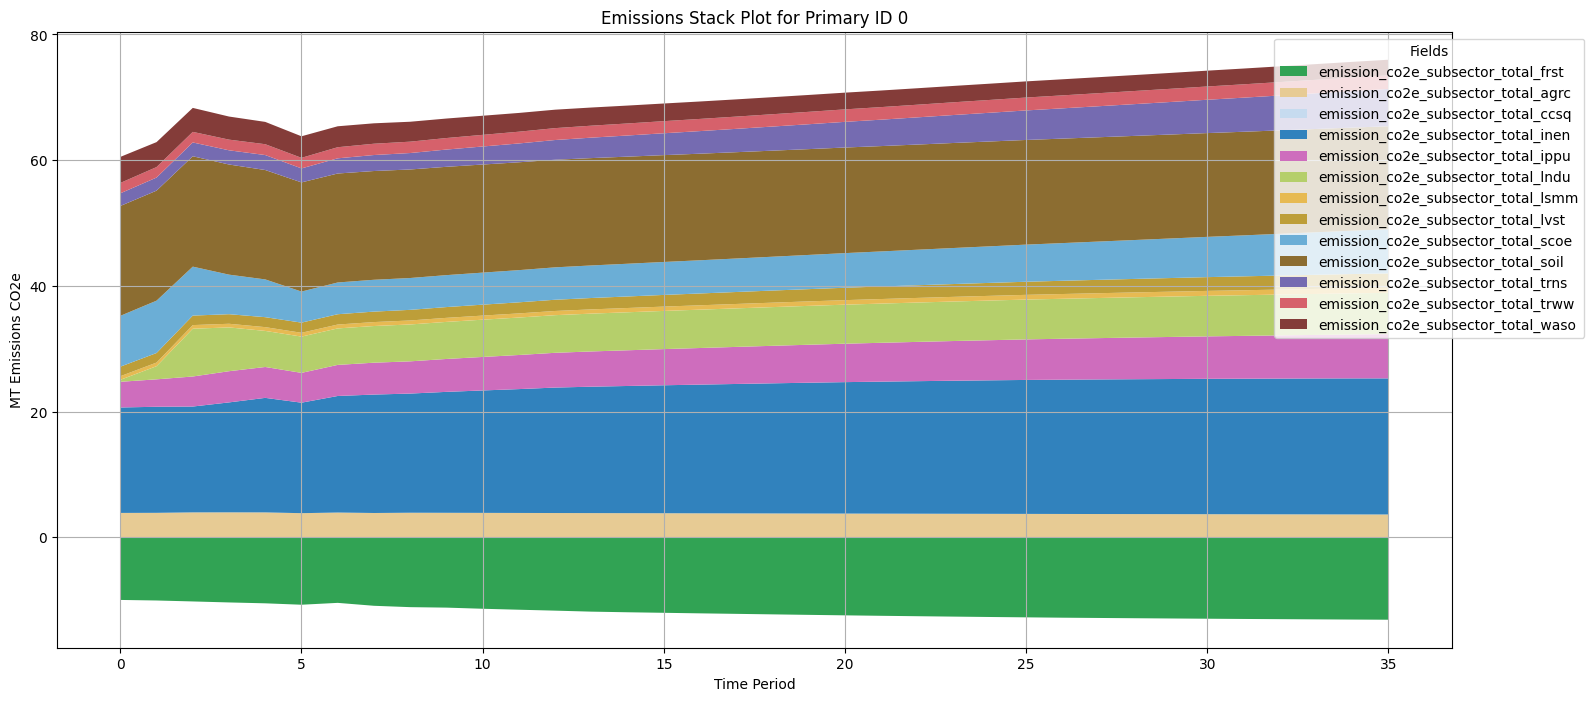

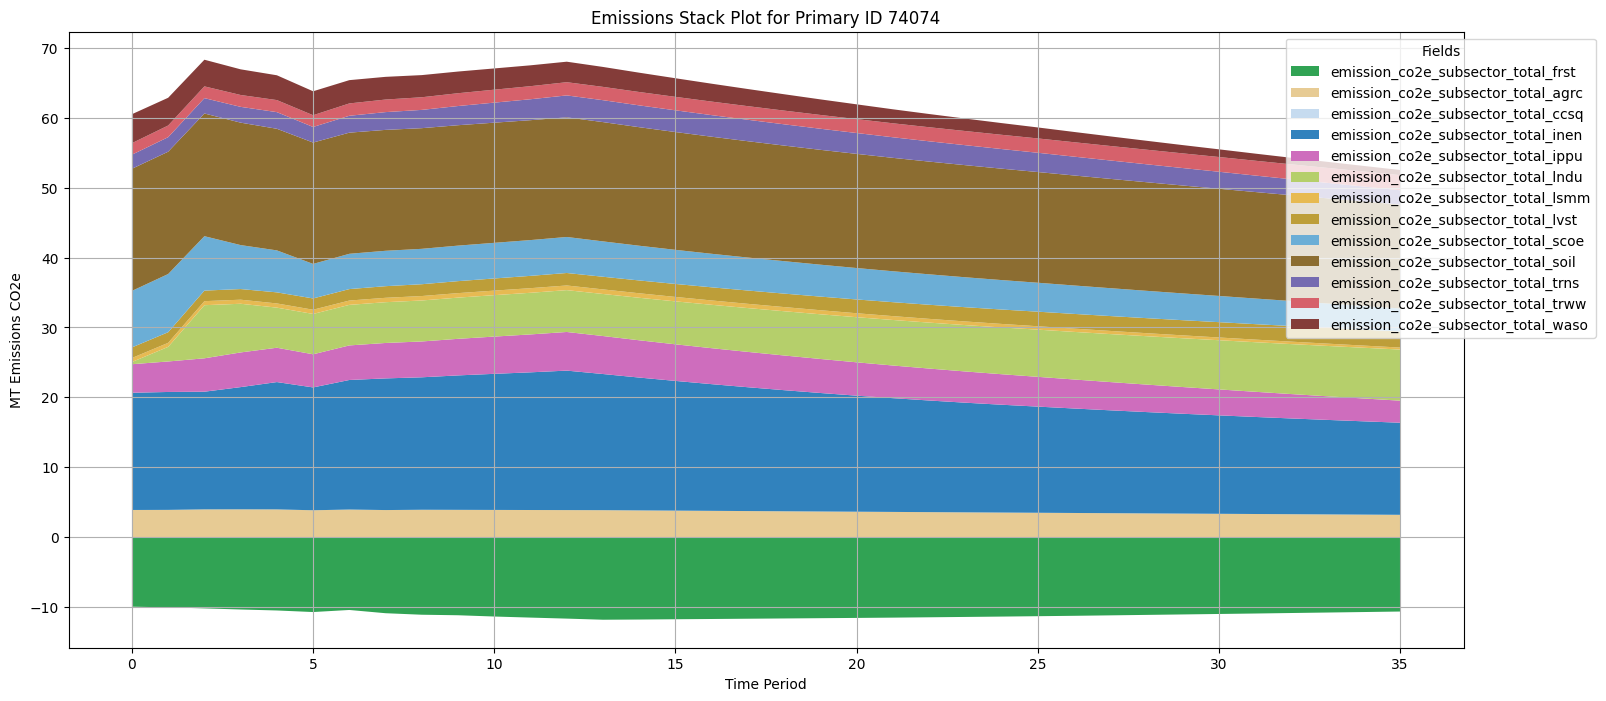

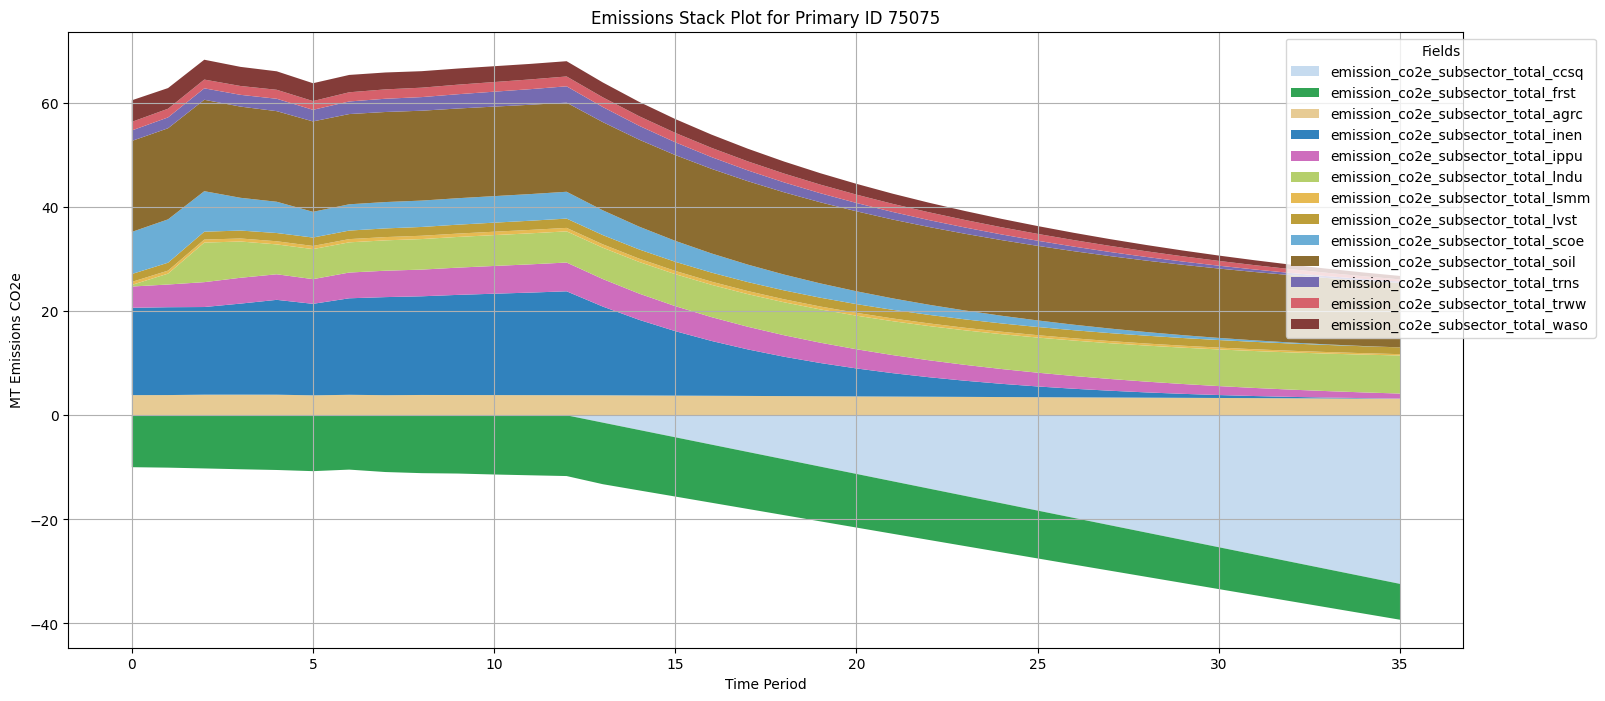

In [91]:
# Plot the emissions stack for the primary_id 0 (which is the baseline)
for primary_id in primary_ids_to_plot:

    plot_field_stack(
        df_out,
        subsector_emission_fields,
        dict_format,
        primary_id=primary_id,
        title=f"Emissions Stack Plot for Primary ID {primary_id}"
    )

In [92]:
# lvst_emission_subsectors = [
#     'emission_co2e_subsector_total_lsmm',
#     'emission_co2e_subsector_total_lvst',
#     'emission_co2e_subsector_total_agrc'
# ]
# for primary_id in primary_ids_to_plot:

#     plot_field_stack(
#         df_out,
#         lvst_emission_subsectors,
#         dict_format,
#         primary_id=primary_id,
#         title=f"Agriculture Emissions Stack Plot for Primary ID {primary_id}"
#     )

## Check Inventory Crop Emissions

In [93]:
inventory_df = pd.read_csv("/Users/tony/Documents/sisepuede_modeling/ssp_bulgaria/ssp_modeling/output_postprocessing/data/emission_targets_bulgaria_2022.csv")
inventory_df.head()

,Subsector,Gas,Edgar_Sector,Edgar_Subsector,Edgar_Subsector_Synthetic,Vars,id,BGR,Edgar_Class
0,agrc,CH4,Agriculture,AG - Crops,AG - Crops,emission_co2e_ch4_agrc_anaerobicdom_rice:emiss...,AG - Crops - CH4,0.106690,AG - Crops:CH4
1,agrc,CO2,Agriculture,AG - Crops,AG - Crops,emission_co2e_co2_agrc_biomass_bevs_and_spices...,AG - Crops - CO2,3.402720,AG - Crops:CO2
2,agrc,N2O,Agriculture,AG - Crops,AG - Crops,emission_co2e_n2o_agrc_biomass_burning:emissio...,AG - Crops - N2O,0.036920,AG - Crops:N2O
3,lvst,CH4,Agriculture,AG - Livestock,AG - Livestock,emission_co2e_ch4_lvst_entferm_buffalo:emissio...,AG - Livestock - CH4,1.669900,AG - Livestock:CH4
4,lsmm,CH4,Agriculture,AG - Livestock,AG - Livestock,emission_co2e_ch4_lsmm_anaerobic_digester:emis...,AG - lsmm-Livestock - CH4,0.306905,AG - Livestock:CH4


emission_co2e_co2_agrc_biomass_other_woody_perennial      1.428984
emission_co2e_co2_agrc_biomass_fruits                     1.051766
emission_co2e_co2_agrc_biomass_nuts                       0.670917
emission_co2e_co2_agrc_biomass_bevs_and_spices            0.198687
emission_co2e_co2_lndu_drained_organic_soils_croplands    0.113115
Name: 7, dtype: float64
3.4634693291653043


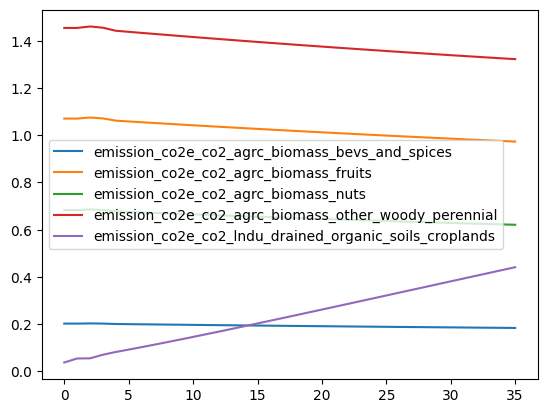

In [94]:
co2_crop_fields = get_vars_by_id(inventory_df, "AG - Crops - CO2")
df_out[df_out.primary_id == 0][co2_crop_fields].plot()
print(df_out[df_out.primary_id == 0][co2_crop_fields].loc[7].sort_values(ascending=False))
print(df_out[df_out.primary_id == 0][co2_crop_fields].loc[7].sum())

emission_co2e_n2o_agrc_crop_residues      0.402025
emission_co2e_n2o_agrc_biomass_burning    0.007181
Name: 7, dtype: float64
0.4092054294664431


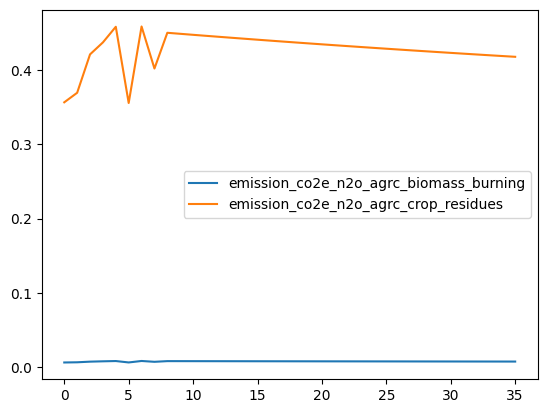

In [95]:
n2o_crop_fields = get_vars_by_id(inventory_df, "AG - Crops - N2O")
df_out[df_out.primary_id == 0][n2o_crop_fields].plot()
print(df_out[df_out.primary_id == 0][n2o_crop_fields].loc[7].sort_values(ascending=False))
print(df_out[df_out.primary_id == 0][n2o_crop_fields].loc[7].sum())

emission_co2e_ch4_agrc_anaerobicdom_rice    0.079249
emission_co2e_ch4_agrc_biomass_burning      0.027916
Name: 7, dtype: float64
0.10716539591665619


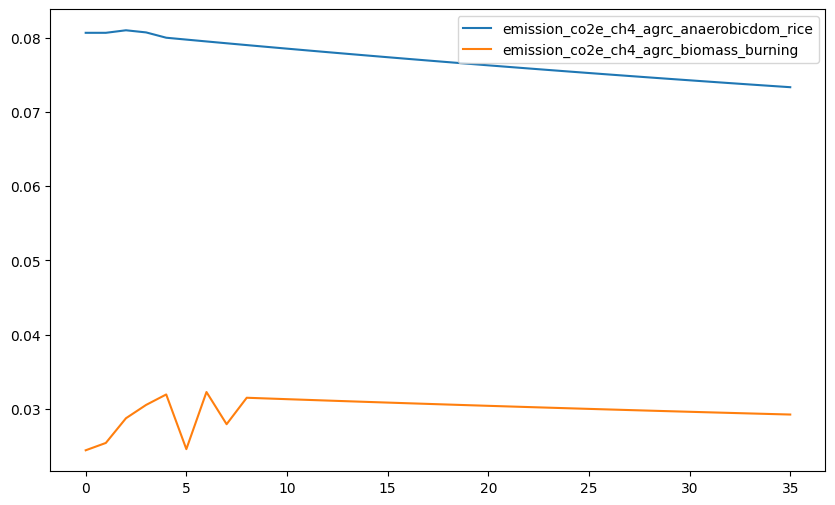

In [96]:
ch4_crop_fields = get_vars_by_id(inventory_df, "AG - Crops - CH4")
df_out[df_out.primary_id == 0][ch4_crop_fields].plot(figsize=(10,6))
print(df_out[df_out.primary_id == 0][ch4_crop_fields].loc[7].sort_values(ascending=False))
print(df_out[df_out.primary_id == 0][ch4_crop_fields].loc[7].sum())

emission_co2e_co2_lndu_drained_organic_soils_pastures    0.026035
emission_co2e_co2_soil_soc_mineral_soils                 0.020747
emission_co2e_co2_soil_urea_use                          0.013898
emission_co2e_co2_soil_lime_use                          0.010130
Name: 7, dtype: float64
0.07080998682711401


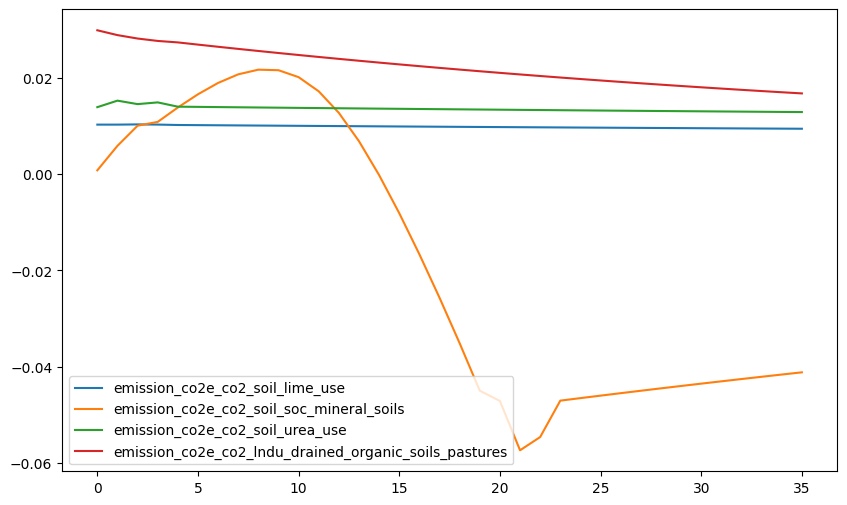

In [97]:
co2_organic_soil_fields = get_vars_by_id(inventory_df, "LULUCF - Organic Soil - CO2")
df_out[df_out.primary_id == 0][co2_organic_soil_fields].plot(figsize=(10,6))
print(df_out[df_out.primary_id == 0][co2_organic_soil_fields].loc[7].sort_values(ascending=False))
print(df_out[df_out.primary_id == 0][co2_organic_soil_fields].loc[7].sum())

emission_co2e_n2o_soil_fertilizer               14.936219
emission_co2e_n2o_soil_organic_soils             2.246334
emission_co2e_n2o_soil_paddock_pasture_range     0.075144
emission_co2e_n2o_soil_mineral_soils             0.002141
Name: 7, dtype: float64
17.25983814473313


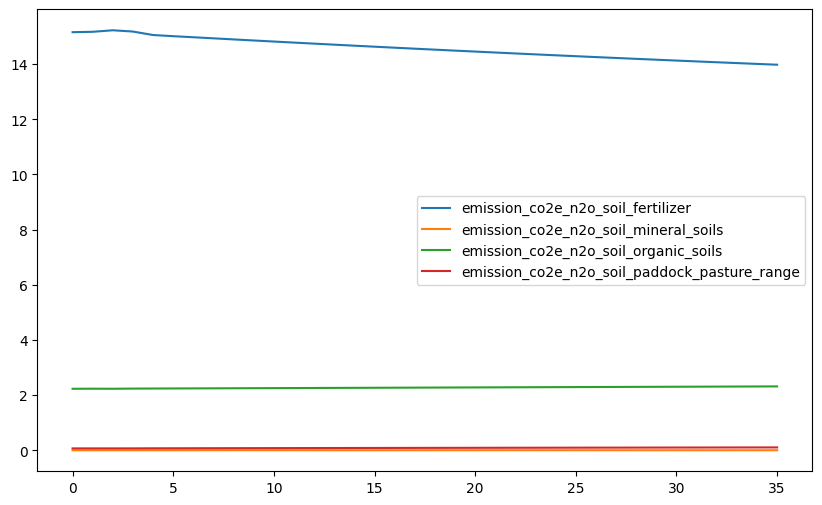

In [98]:
n2o_organic_soil_fields = get_vars_by_id(inventory_df, "LULUCF - Organic Soil - N2O")
df_out[df_out.primary_id == 0][n2o_organic_soil_fields].plot(figsize=(10,6))
print(df_out[df_out.primary_id == 0][n2o_organic_soil_fields].loc[7].sort_values(ascending=False))
print(df_out[df_out.primary_id == 0][n2o_organic_soil_fields].loc[7].sum())

## Check Inventory IPPU Emissions

In [99]:
inventory_df[inventory_df.Subsector == "ippu"].head()

,Subsector,Gas,Edgar_Sector,Edgar_Subsector,Edgar_Subsector_Synthetic,Vars,id,BGR,Edgar_Class
27,ippu,CH4,Industrial Processes,IN - Industrial Processes,IN - Industrial Processes,emission_co2e_ch4_ippu_production_chemicals:em...,IN - Industrial Processes - CH4,0.00000,IN - Industrial Processes:CH4
28,ippu,CO2,Industrial Processes,IN - Industrial Processes,IN - Industrial Processes,emission_co2e_co2_ippu_product_use_product_use...,IN - Industrial Processes - CO2,3.77808,IN - Industrial Processes:CO2
29,ippu,HFC,Industrial Processes,IN - Industrial Processes,IN - Industrial Processes,emission_co2e_hfcs_ippu_product_use_product_us...,IN - Industrial Processes - HFC,0.70185,IN - Industrial Processes:HFC
30,ippu,N2O,Industrial Processes,IN - Industrial Processes,IN - Industrial Processes,emission_co2e_n2o_ippu_production_chemicals:em...,IN - Industrial Processes - N2O,0.07987,IN - Industrial Processes:N2O
31,ippu,OTHER_FCS,Industrial Processes,IN - Industrial Processes,IN - Industrial Processes,emission_co2e_other_fcs_ippu_product_use_produ...,IN - Industrial Processes - OTHER_FCS,0.00000,IN - Industrial Processes:OTHER_FCS


emission_co2e_co2_ippu_production_metals                       1.680922
emission_co2e_co2_ippu_production_cement                       1.076238
emission_co2e_co2_ippu_production_lime_and_carbonite           0.694179
emission_co2e_co2_ippu_production_plastic                      0.042714
emission_co2e_co2_ippu_product_use_product_use_lubricants      0.019140
emission_co2e_co2_ippu_product_use_product_use_paraffin_wax    0.016843
emission_co2e_co2_ippu_production_glass                        0.011860
emission_co2e_co2_ippu_production_chemicals                    0.005714
emission_co2e_co2_ippu_product_use_product_use_other           0.001215
emission_co2e_co2_ippu_production_paper                        0.000000
emission_co2e_co2_ippu_production_product_use_lubricants       0.000000
emission_co2e_co2_ippu_production_product_use_paraffin_wax     0.000000
Name: 7, dtype: float64
3.548823782539753


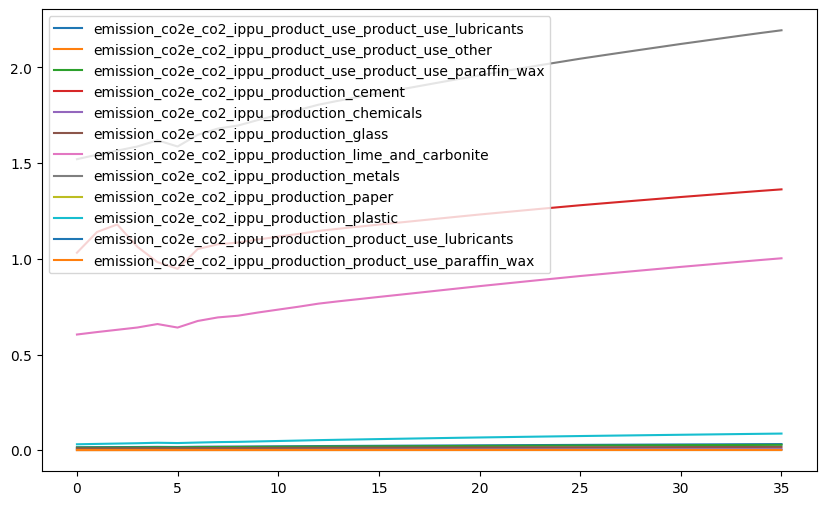

In [100]:
co2_ippu_fields = get_vars_by_id(inventory_df, "IN - Industrial Processes - CO2")

df_out[df_out.primary_id == 0][co2_ippu_fields].plot(figsize=(10,6))
print(df_out[df_out.primary_id == 0][co2_ippu_fields].loc[7].sort_values(ascending=False))
print(df_out[df_out.primary_id == 0][co2_ippu_fields].loc[7].sum())

emission_co2e_n2o_ippu_production_chemicals                      0.068738
emission_co2e_n2o_ippu_production_other_product_manufacturing    0.004759
emission_co2e_n2o_ippu_production_paper                          0.000000
emission_co2e_n2o_ippu_production_plastic                        0.000000
Name: 7, dtype: float64
0.0734963427853893


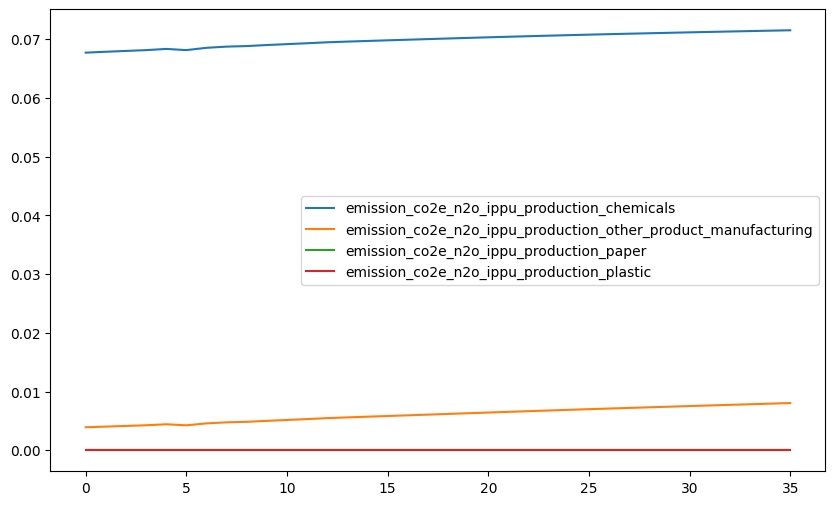

In [101]:
n2o_ippu_fields = get_vars_by_id(inventory_df, "IN - Industrial Processes - N2O")

df_out[df_out.primary_id == 0][n2o_ippu_fields].plot(figsize=(10,6))
print(df_out[df_out.primary_id == 0][n2o_ippu_fields].loc[7].sort_values(ascending=False))
print(df_out[df_out.primary_id == 0][n2o_ippu_fields].loc[7].sum())

emission_co2e_hfcs_ippu_production_electronics                       0.295141
emission_co2e_hfcs_ippu_product_use_product_use_ods_refrigeration    0.236649
emission_co2e_hfcs_ippu_product_use_product_use_ods_other            0.176863
emission_co2e_hfcs_ippu_production_chemicals                         0.000000
emission_co2e_hfcs_ippu_production_metals                            0.000000
Name: 7, dtype: float64
0.7086529657059996


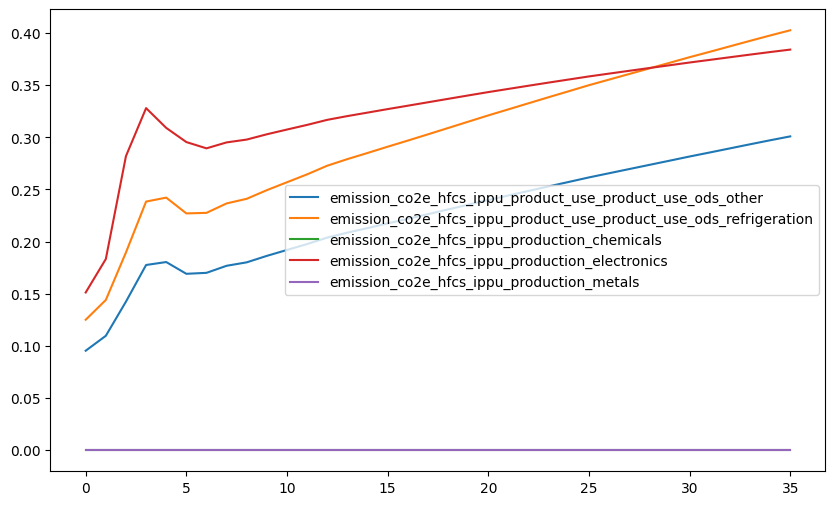

In [102]:
hfc_ippu_fields = get_vars_by_id(inventory_df, "IN - Industrial Processes - HFC")

df_out[df_out.primary_id == 0][hfc_ippu_fields].plot(figsize=(10,6))
print(df_out[df_out.primary_id == 0][hfc_ippu_fields].loc[7].sort_values(ascending=False))
print(df_out[df_out.primary_id == 0][hfc_ippu_fields].loc[7].sum())

emission_co2e_sf6_ippu_production_other_product_manufacturing    0.021303
emission_co2e_sf6_ippu_production_electronics                    0.001703
emission_co2e_sf6_ippu_production_chemicals                      0.000000
emission_co2e_sf6_ippu_production_metals                         0.000000
Name: 7, dtype: float64
0.0230055842928284


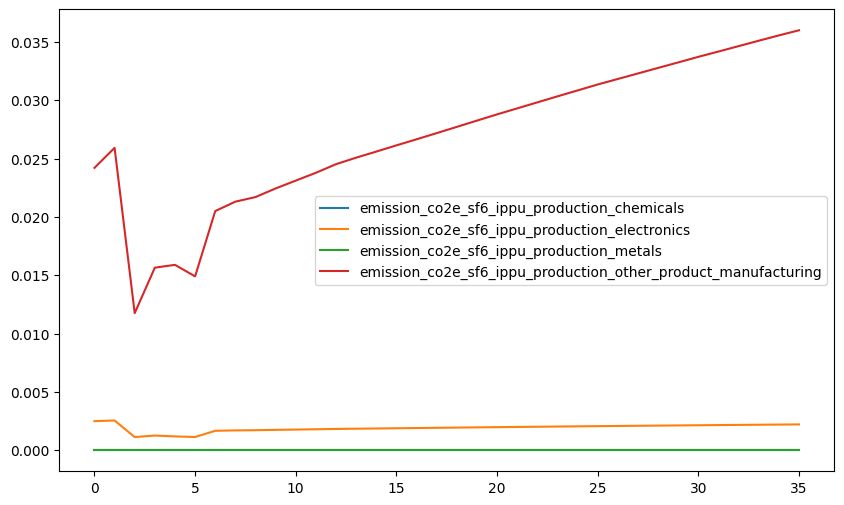

In [103]:
sf6_ippu_fields = get_vars_by_id(inventory_df, "IN - Industrial Processes - SF6")

df_out[df_out.primary_id == 0][sf6_ippu_fields].plot(figsize=(10,6))
print(df_out[df_out.primary_id == 0][sf6_ippu_fields].loc[7].sort_values(ascending=False))
print(df_out[df_out.primary_id == 0][sf6_ippu_fields].loc[7].sum())

emission_co2e_ch4_ippu_production_metals       0.004361
emission_co2e_ch4_ippu_production_plastic      0.003286
emission_co2e_ch4_ippu_production_chemicals    0.000218
emission_co2e_ch4_ippu_production_paper        0.000000
Name: 7, dtype: float64
0.0078645468884501


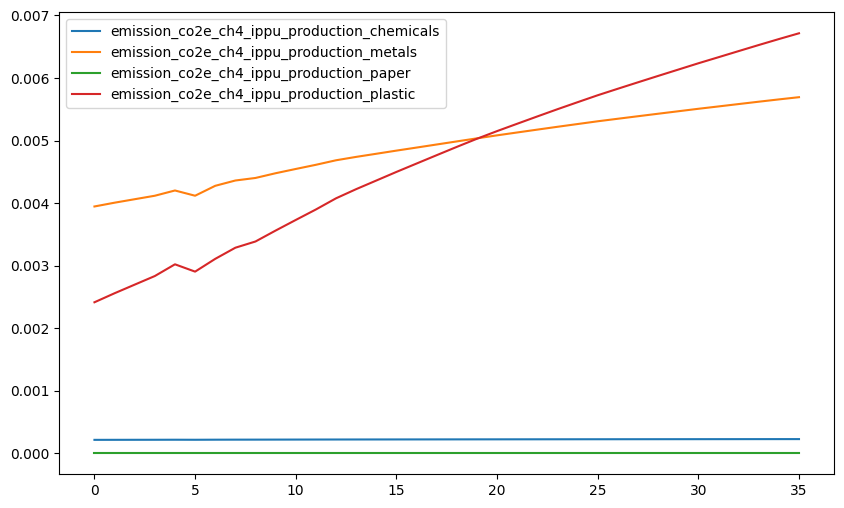

In [104]:
ch4_ippu_fields = get_vars_by_id(inventory_df, "IN - Industrial Processes - CH4")

df_out[df_out.primary_id == 0][ch4_ippu_fields].plot(figsize=(10,6))
print(df_out[df_out.primary_id == 0][ch4_ippu_fields].loc[7].sort_values(ascending=False))
print(df_out[df_out.primary_id == 0][ch4_ippu_fields].loc[7].sum())

## Check Livestock inventory emissions

In [105]:
inventory_df[inventory_df.Subsector == "lsmm"].head()

,Subsector,Gas,Edgar_Sector,Edgar_Subsector,Edgar_Subsector_Synthetic,Vars,id,BGR,Edgar_Class
4,lsmm,CH4,Agriculture,AG - Livestock,AG - Livestock,emission_co2e_ch4_lsmm_anaerobic_digester:emis...,AG - lsmm-Livestock - CH4,0.306905,AG - Livestock:CH4
5,lsmm,N2O,Agriculture,AG - Livestock,AG - Livestock,emission_co2e_n2o_lsmm_direct_anaerobic_digest...,AG - Livestock - N2O,0.306905,AG - Livestock:N2O


In [106]:
ch4_lvst_fields = get_vars_by_id(inventory_df, "AG - Livestock - CH4")
n2o_lvst_fields = get_vars_by_id(inventory_df, "AG - Livestock - N2O")
ch4_lsmm_fields = get_vars_by_id(inventory_df, "AG - lsmm-Livestock - CH4")

emission_co2e_ch4_lsmm_liquid_slurry            0.252227
emission_co2e_ch4_lsmm_storage_solid            0.041707
emission_co2e_ch4_lsmm_anaerobic_lagoon         0.014424
emission_co2e_ch4_lsmm_paddock_pasture_range    0.003708
emission_co2e_ch4_lsmm_poultry_manure           0.002497
emission_co2e_ch4_lsmm_dry_lot                  0.000945
emission_co2e_ch4_lsmm_daily_spread             0.000427
emission_co2e_ch4_lsmm_anaerobic_digester       0.000000
emission_co2e_ch4_lsmm_composting               0.000000
emission_co2e_ch4_lsmm_deep_bedding             0.000000
emission_co2e_ch4_lsmm_incineration             0.000000
Name: 7, dtype: float64
0.3159331016890869


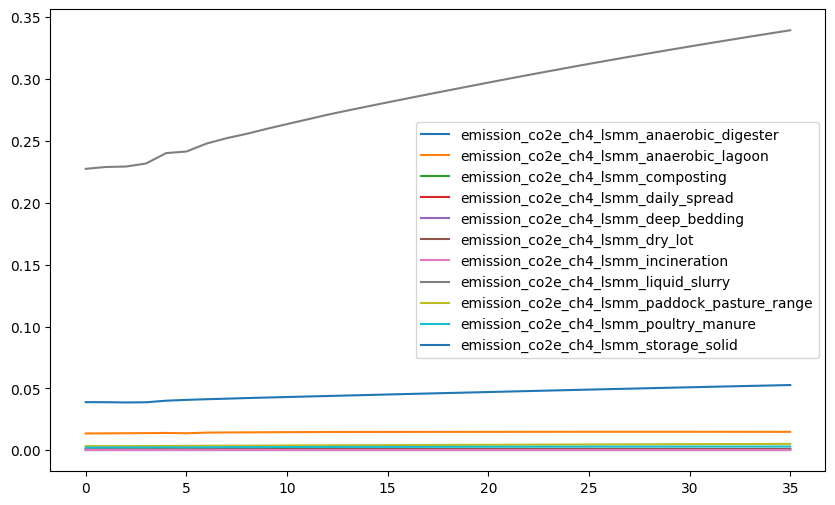

In [107]:
df_out[df_out.primary_id == 0][ch4_lsmm_fields].plot(figsize=(10,6))
print(df_out[df_out.primary_id == 0][ch4_lsmm_fields].loc[7].sort_values(ascending=False))
print(df_out[df_out.primary_id == 0][ch4_lsmm_fields].loc[7].sum())

emission_co2e_ch4_lvst_entferm_cattle_dairy       0.734782
emission_co2e_ch4_lvst_entferm_cattle_nondairy    0.460831
emission_co2e_ch4_lvst_entferm_sheep              0.330013
emission_co2e_ch4_lvst_entferm_goats              0.064913
emission_co2e_ch4_lvst_entferm_horses             0.026622
emission_co2e_ch4_lvst_entferm_pigs               0.021232
emission_co2e_ch4_lvst_entferm_buffalo            0.019712
emission_co2e_ch4_lvst_entferm_mules              0.006872
emission_co2e_ch4_lvst_entferm_chickens           0.000000
Name: 7, dtype: float64
1.6649767103465931


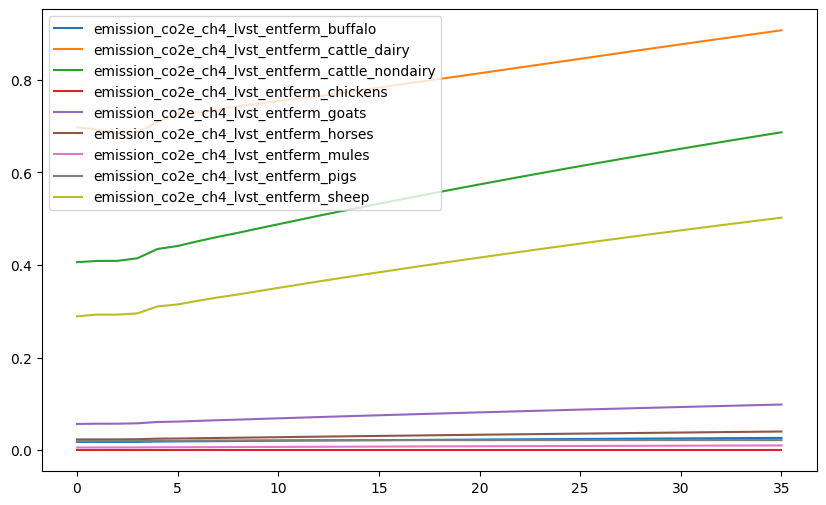

In [108]:
df_out[df_out.primary_id == 0][ch4_lvst_fields].plot(figsize=(10,6))
print(df_out[df_out.primary_id == 0][ch4_lvst_fields].loc[7].sort_values(ascending=False))
print(df_out[df_out.primary_id == 0][ch4_lvst_fields].loc[7].sum())

emission_co2e_n2o_lsmm_direct_storage_solid              0.171367
emission_co2e_n2o_lsmm_indirect_storage_solid            0.056537
emission_co2e_n2o_lsmm_direct_liquid_slurry              0.028917
emission_co2e_n2o_lsmm_direct_dry_lot                    0.024355
emission_co2e_n2o_lsmm_indirect_liquid_slurry            0.020449
emission_co2e_n2o_lsmm_direct_poultry_manure             0.002978
emission_co2e_n2o_lsmm_indirect_dry_lot                  0.002897
emission_co2e_n2o_lsmm_indirect_poultry_manure           0.002074
emission_co2e_n2o_lsmm_indirect_anaerobic_lagoon         0.000968
emission_co2e_n2o_lsmm_indirect_daily_spread             0.000828
emission_co2e_n2o_lsmm_indirect_paddock_pasture_range    0.000000
emission_co2e_n2o_lsmm_indirect_incineration             0.000000
emission_co2e_n2o_lsmm_indirect_deep_bedding             0.000000
emission_co2e_n2o_lsmm_direct_anaerobic_digester         0.000000
emission_co2e_n2o_lsmm_indirect_composting               0.000000
emission_c

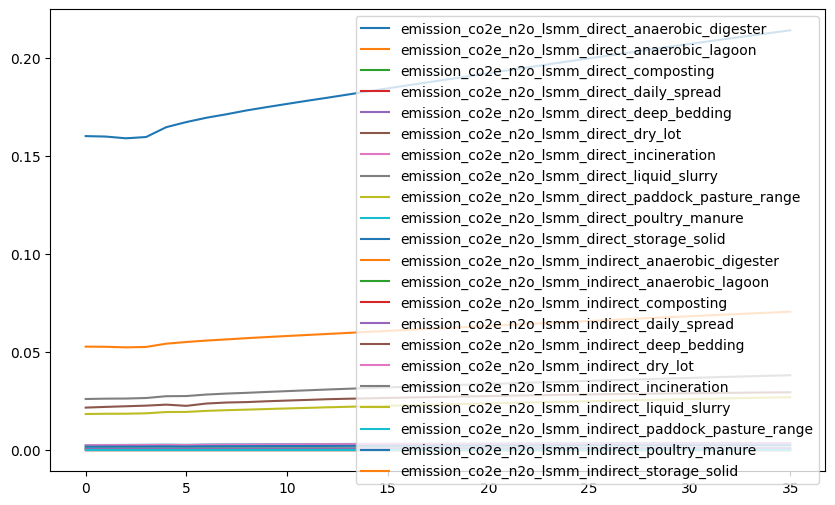

In [109]:
df_out[df_out.primary_id == 0][n2o_lvst_fields].plot(figsize=(10,6))
print(df_out[df_out.primary_id == 0][n2o_lvst_fields].loc[7].sort_values(ascending=False))
print(df_out[df_out.primary_id == 0][n2o_lvst_fields].loc[7].sum())

### LNDU Area check


In [96]:
# lndu_area_type_fields = matt.get_variable("Land Use Area").fields
# for primary_id in primary_ids_to_plot:

#     plot_field_stack(
#         df_out,
#         ["area_lndu_forests_secondary"],
#         dict_format,
#         primary_id=primary_id,
#         title=f"Land Use Area Stack Plot for Primary ID {primary_id}"
#     )


### IPPU Production

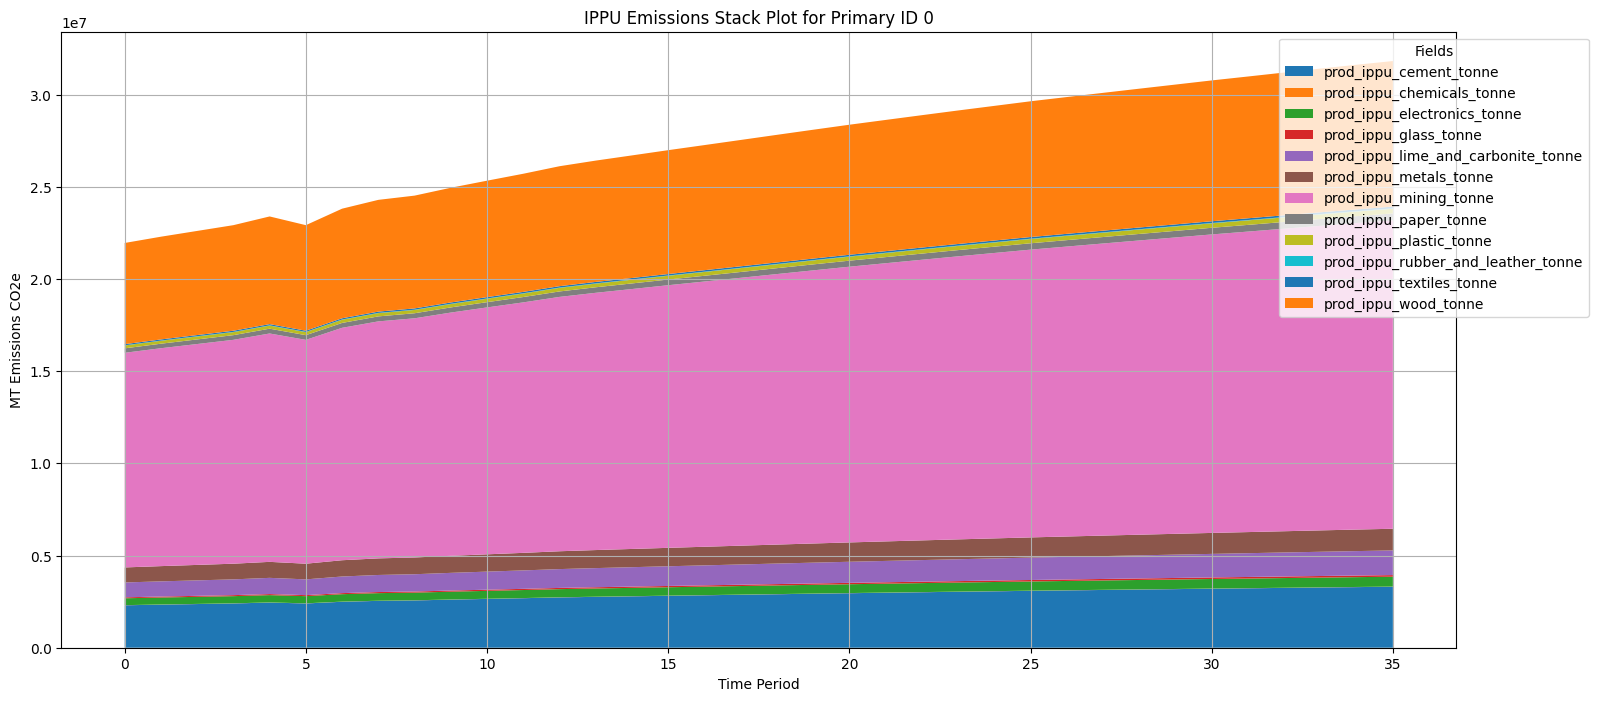

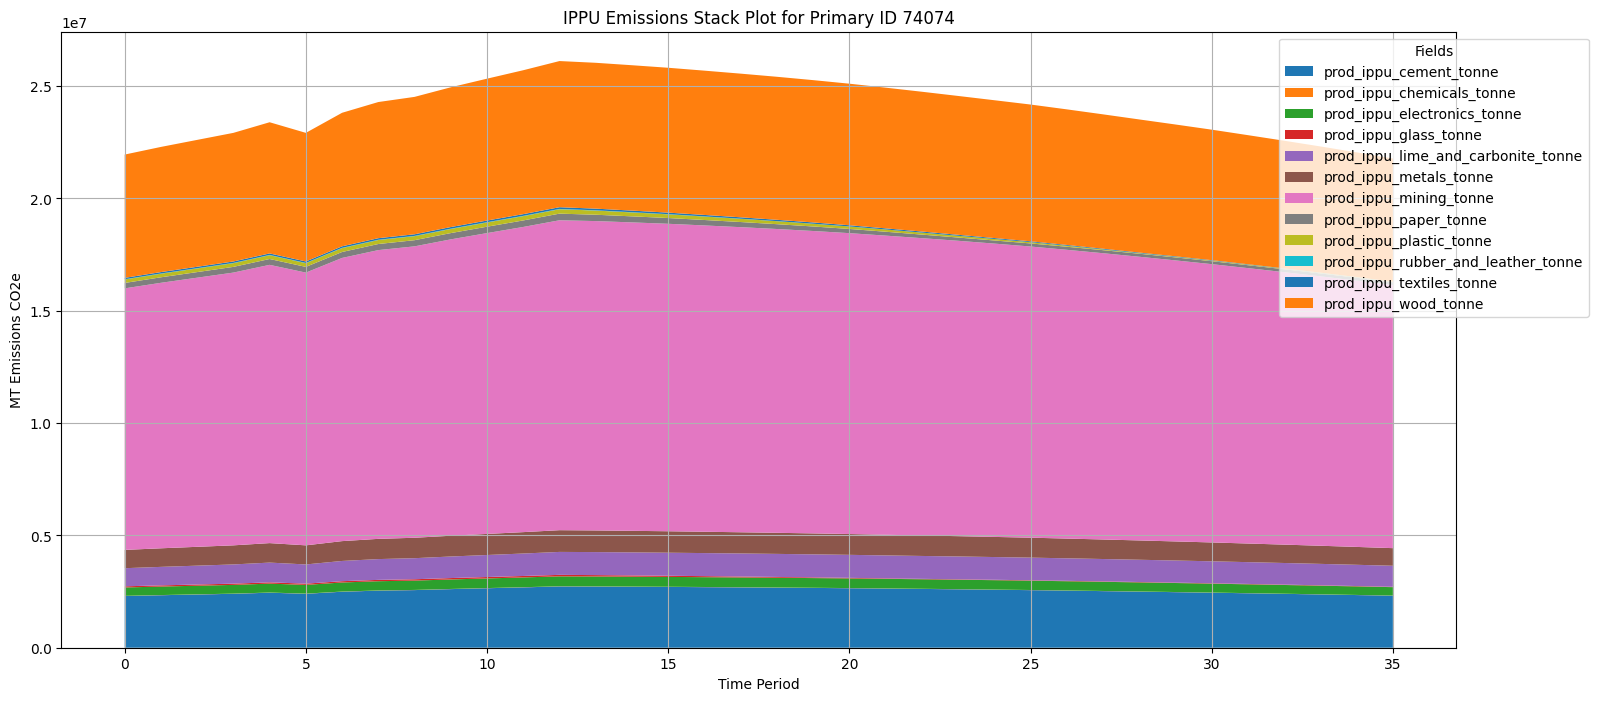

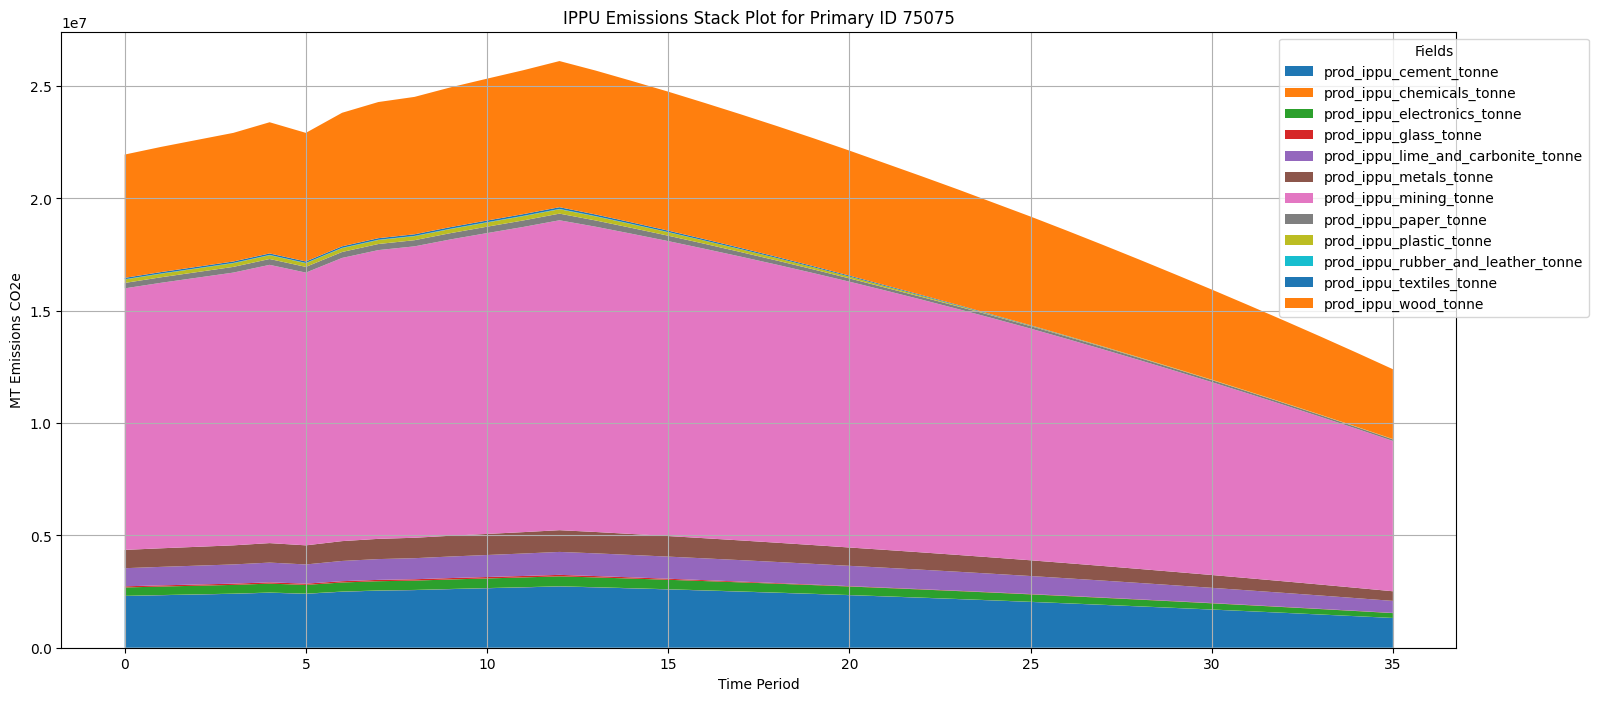

prod_ippu_mining_tonne                1.285360e+07
prod_ippu_wood_tonne                  6.060552e+06
prod_ippu_cement_tonne                2.542267e+06
prod_ippu_lime_and_carbonite_tonne    9.255717e+05
prod_ippu_metals_tonne                9.004595e+05
prod_ippu_electronics_tonne           4.119195e+05
prod_ippu_paper_tonne                 2.708149e+05
prod_ippu_plastic_tonne               1.782714e+05
prod_ippu_textiles_tonne              7.012332e+04
prod_ippu_glass_tonne                 5.929920e+04
prod_ippu_rubber_and_leather_tonne    1.117813e+04
prod_ippu_chemicals_tonne             6.730456e+03
Name: 7, dtype: float64


In [97]:
ippu_production_fields = matt.get_variable("Industrial Production").fields

for primary_id in primary_ids_to_plot:

    plot_field_stack(
        df_out,
        ippu_production_fields,
        dict_format,
        primary_id=primary_id,
        title=f"IPPU Emissions Stack Plot for Primary ID {primary_id}"
    )

print(df_out[df_out.primary_id == 0][ippu_production_fields].loc[7].sort_values(ascending=False))

In [98]:
# ippu_fields = ['emission_co2e_subsector_total_ippu']

# for primary_id in primary_ids_to_plot:

#     plot_field_stack(
#         df_out,
#         ippu_fields,
#         dict_format,
#         primary_id=primary_id,
#         title=f"IPPU Emissions Stack Plot for Primary ID {primary_id}"
#     )

In [99]:
# waste_fields = [
#     'emission_co2e_subsector_total_waso',
#     'emission_co2e_subsector_total_trww',
# ]

# for primary_id in primary_ids_to_plot:

#     plot_field_stack(
#         df_out,
#         waste_fields,
#         dict_format,
#         primary_id=primary_id,
#         title=f"Waste Emissions Stack Plot for Primary ID {primary_id}"
#     )


In [100]:
# subsector_emission_fields

In [101]:
# df_out['emission_co2e_subsector_total_fgtv']

In [102]:
# fgtv_fields = ['emission_co2e_subsector_total_fgtv']

# for primary_id in primary_ids_to_plot:

#     plot_field_stack(
#         df_out,
#         fgtv_fields,
#         dict_format,
#         primary_id=primary_id,
#         title=f"FGTV Emissions Stack Plot for Primary ID {primary_id}"
#     )

In [103]:
# fgtv_fields = ['emission_co2e_subsector_total_trns']

# for primary_id in primary_ids_to_plot:

#     plot_field_stack(
#         df_out,
#         fgtv_fields,
#         dict_format,
#         primary_id=primary_id,
#         title=f"Transport Emissions Stack Plot for Primary ID {primary_id}"
#     )

In [104]:
# # Plot non energy emissions stack
# non_energy_fields = [
# 'emission_co2e_subsector_total_agrc',
#  'emission_co2e_subsector_total_frst',
#  'emission_co2e_subsector_total_lndu',
#  'emission_co2e_subsector_total_lsmm',
#  'emission_co2e_subsector_total_lvst',
#  'emission_co2e_subsector_total_soil',
#  'emission_co2e_subsector_total_waso',
#  'emission_co2e_subsector_total_trww',
#  'emission_co2e_subsector_total_ippu'
# ]

# for primary_id in primary_ids_to_plot:

#     plot_field_stack(
#         df_out,
#         non_energy_fields,
#         dict_format,
#         primary_id=primary_id,
#         title=f"Emissions Stack Plot for Primary ID {primary_id}"
#     )

## Check Crop Demand and Yield


In [105]:
# crop_demand_fields = [col for col in df_out.columns if 'demand_agrc_' in col]
# crop_yield_fields = [col for col in df_out.columns if 'yield_agrc_' in col]

In [106]:
# for primary_id in primary_ids_to_plot:

#     plot_field_stack(
#         df_out,
#         crop_demand_fields,
#         dict_format,
#         primary_id=primary_id,
#         title=f"Crop Demand Over Time for Primary ID {primary_id}",
#         ylabel="Crop Demand (Tonnes)"
#     )
#     print(df_out[df_out[ssp.key_primary]==primary_id][crop_demand_fields].iloc[7])

In [107]:
# for primary_id in primary_ids_to_plot:

#     plot_field_stack(
#         df_out,
#         crop_yield_fields,
#         dict_format,
#         primary_id=primary_id,
#         title=f"Crop Yield Over Time for Primary ID {primary_id}",
#         ylabel="Crop Yield (Tonnes/Ha)"
#     )

#     print(df_out[df_out[ssp.key_primary]==primary_id][crop_yield_fields].iloc[7].sort_values(ascending=False))

In [108]:
# yield_factor_fields = matt.get_variable("Crop Yield Factor").fields

# for primary_id in primary_ids_to_plot:
#     plot_field_stack(
#         df_in,
#         yield_factor_fields,
#         dict_format,
#         primary_id=primary_id,
#         title=f"Crop Yield Factor Over Time for Primary ID {primary_id}",
#         ylabel="Crop Yield Factor"
#     )
#     print(df_in[df_in[ssp.key_primary]==primary_id][yield_factor_fields].iloc[7].sort_values(ascending=False))

### Livestock Check

In [109]:
# lvst_pop_fields = matt.get_variable("Livestock Head Count").fields

# for primary_id in primary_ids_to_plot:
#     plot_field_stack(
#         df_out,
#         lvst_pop_fields,
#         dict_format,
#         primary_id=primary_id,
#         title=f"Livestock Head Count Over Time for Primary ID {primary_id}"
# )

In [110]:
# crop_residues_fields = ["emission_co2e_n2o_agrc_crop_residues"]

# for primary_id in primary_ids_to_plot:

#     plot_field_stack(
#         df_out,
#         crop_residues_fields,
#         dict_format,
#         primary_id=primary_id,
#         title=f"Crop Residues Emissions Over Time for Primary ID {primary_id}",
#         ylabel="MT Emissions CO2e from Crop Residues"
#     )

In [111]:
# co2_agrc_fields = [
#     "emission_co2e_co2_agrc_biomass_bevs_and_spices",
#     "emission_co2e_co2_agrc_biomass_fruits",
#     "emission_co2e_co2_agrc_biomass_nuts",
#     "emission_co2e_co2_agrc_biomass_other_woody_perennial",
# ]
# for primary_id in primary_ids_to_plot:

#     plot_field_stack(
#         df_out,
#         co2_agrc_fields,
#         dict_format,
#         primary_id=primary_id,
#         title=f"CO2 Agriculture Emissions Over Time for Primary ID {primary_id}",
#         ylabel="MT CO2 Emissions"
#     )

#     print(df_out[df_out[ssp.key_primary]==primary_id][co2_agrc_fields].iloc[-1].sort_values(ascending=False))

In [112]:
# ch4_agrc_fields = ["emission_co2e_ch4_agrc_anaerobicdom_rice", "emission_co2e_ch4_agrc_biomass_burning"]
# for primary_id in primary_ids_to_plot:

#     plot_field_stack(
#         df_out,
#         ch4_agrc_fields,
#         dict_format,
#         primary_id=primary_id,
#         title=f"CH4 Agriculture Emissions Over Time for Primary ID {primary_id}",
#         ylabel="MT CH4 Emissions"
#     )

#     print(df_out[df_out[ssp.key_primary]==primary_id][ch4_agrc_fields].iloc[-1].sort_values(ascending=False))

In [113]:
# n20_agrc_fields = ["emission_co2e_n2o_agrc_biomass_burning", "emission_co2e_n2o_agrc_crop_residues"]
# for primary_id in primary_ids_to_plot:

#     plot_field_stack(
#         df_out,
#         n20_agrc_fields,
#         dict_format,
#         primary_id=primary_id,
#         title=f"N2O Agriculture Emissions Over Time for Primary ID {primary_id}",
#         ylabel="MT N2O Emissions"
#     )

#     print(df_out[df_out[ssp.key_primary]==primary_id][n20_agrc_fields].iloc[-1].sort_values(ascending=False))

## Fix FGTV when having super large spikes (Only use when there are spikes)

<Axes: >

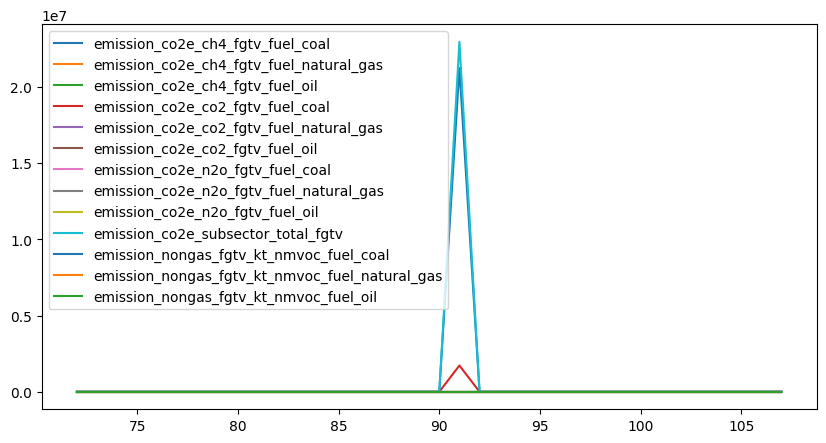

In [114]:
primary_id_to_fix = 75075
df_out[df_out.primary_id==primary_id_to_fix][[col for col in df_out.columns if 'fgtv' in col]].plot(figsize=(10,5))

In [115]:
def hampel_clean(
    s: pd.Series,
    window: int = 7,
    n_sigmas: float = 5.0,
    strategy: str = "prev",  # "prev" | "median" | "linear" | "nan"
):
    """
    Detects spikes using a rolling median + MAD (Hampel) and replaces them.

    Returns
    -------
    cleaned : pd.Series
    mask : pd.Series[bool]  # True where a spike was found
    """
    s = s.astype(float).copy()

    # Rolling median
    med = s.rolling(window, center=True, min_periods=max(3, window//2)).median()

    # Rolling MAD (median absolute deviation)
    def _mad(x):
        m = np.median(x)
        return np.median(np.abs(x - m))
    mad = s.rolling(window, center=True, min_periods=max(3, window//2)).apply(_mad, raw=False)

    # Robust z-score using MAD (~= std when multiplied by 1.4826)
    sigma = 1.4826 * mad
    # Fallbacks at edges
    med = med.fillna(s.median())
    sigma = sigma.replace(0, np.nan).fillna(sigma[sigma>0].median() or 1.0)

    z = (s - med).abs() / sigma
    mask = z > n_sigmas  # spike locations (True = spike)

    # Impute
    cleaned = s.copy()
    if strategy == "prev":
        # copy previous *valid* value
        # (for first element or consecutive spikes, fall back to local median)
        for idx in np.where(mask)[0]:
            if idx > 0 and not np.isnan(cleaned.iloc[idx-1]):
                cleaned.iloc[idx] = cleaned.iloc[idx-1]
            else:
                cleaned.iloc[idx] = med.iloc[idx]
    elif strategy == "median":
        cleaned[mask] = med[mask]
    elif strategy == "linear":
        tmp = cleaned.copy()
        tmp[mask] = np.nan
        cleaned = tmp.interpolate(method="linear", limit_direction="both")
    elif strategy == "nan":
        cleaned[mask] = np.nan
    else:
        raise ValueError("Unknown strategy")

    return cleaned, mask

# --- Example on your Series s ---
# s_clean, spike_mask = hampel_clean(s, window=7, n_sigmas=5.0, strategy="prev")


In [116]:
# select the subset
subset = df_out[df_out.primary_id == primary_id_to_fix].copy()

# get only the relevant columns
cols = [c for c in df_out.columns if 'fgtv' in c]

# make a copy to store cleaned results
cleaned_subset = subset.copy()
spike_masks = {}

# apply Hampel cleaning to each relevant column
for c in cols:
    cleaned_subset[c], spike_masks[c] = hampel_clean(
        subset[c],
        window=7,
        n_sigmas=5.0,
        strategy="prev"  # or "median"/"linear"
    )

# if you want to merge back into df_out:
df_out.loc[df_out.primary_id == primary_id_to_fix, cols] = cleaned_subset[cols]

<Axes: >

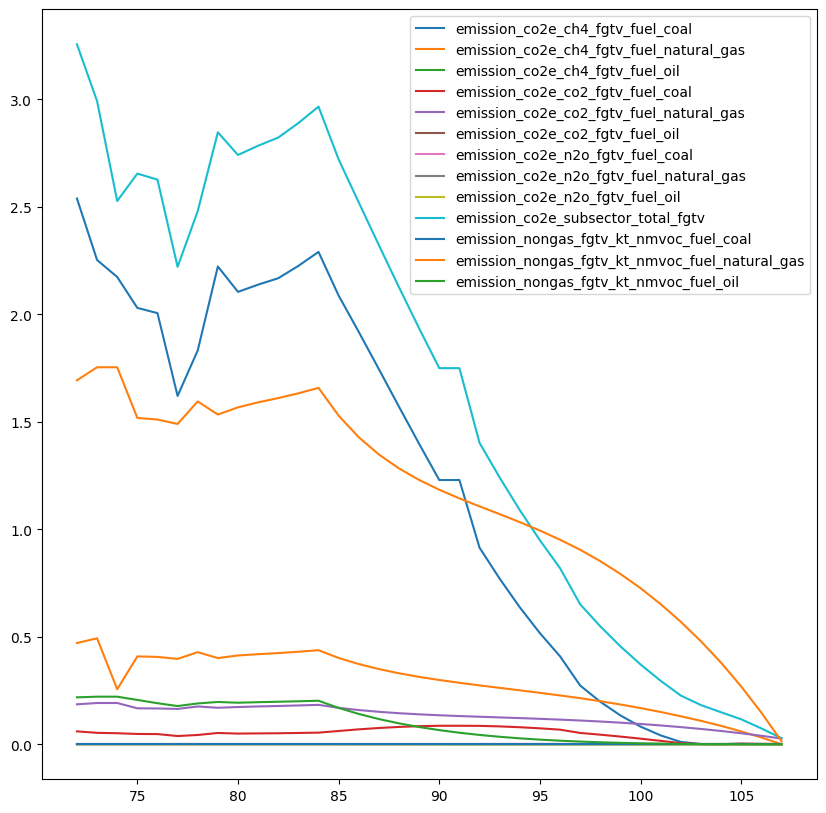

In [117]:
df_out[df_out.primary_id==primary_id_to_fix][[col for col in df_out.columns if 'fgtv' in col]].plot(figsize=(10,10))

<Axes: >

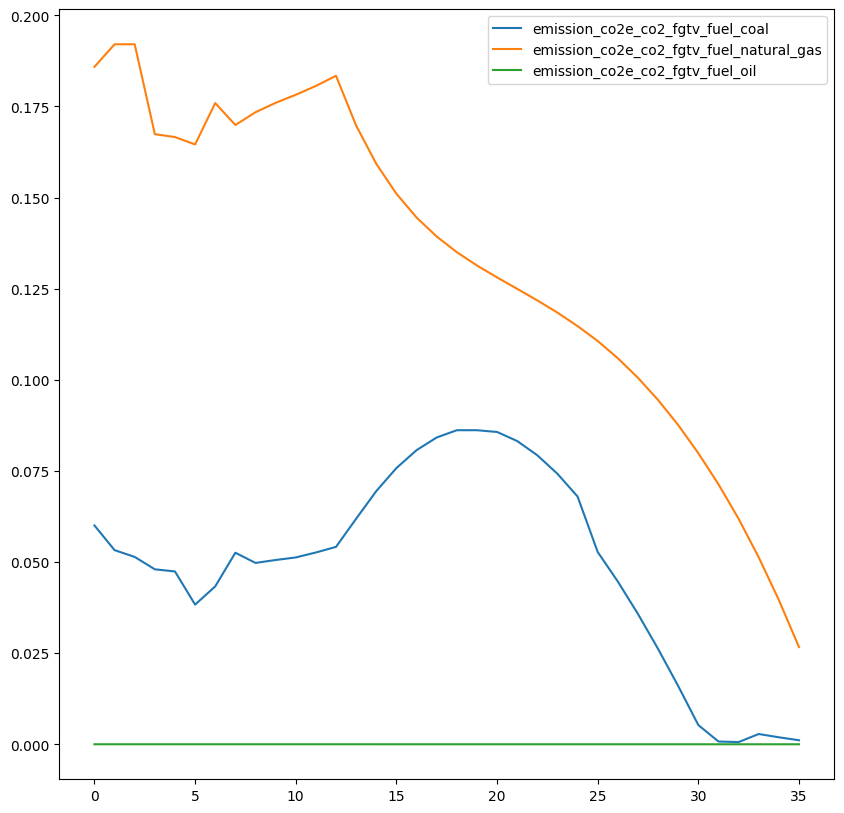

In [118]:
df_out[df_out.primary_id==75075][[col for col in df_out.columns if 'fgtv' in col and 'co2_' in col]].reset_index(drop=True).plot(figsize=(10,10))

# Export Wide File (Last Mandatory Step)

In [119]:
all_primaries = sorted(list(df_out[ssp.key_primary].unique()))

# build if unable to simply read the data frame
if df_in is None:
    df_in = []
     
    for region in ssp.regions:
        for primary in all_primaries: 
            df_in_filt = ssp.generate_scenario_database_from_primary_key(primary)
            df_in.append(df_in_filt.get(region))
    
    df_in = pd.concat(df_in, axis = 0).reset_index(drop = True)




df_export = pd.merge(
    df_out,
    df_in,
    how = "left",
)



# check output directory 
dir_pkg = os.path.join(
    ssp.file_struct.dir_out, 
    f"sisepuede_summary_results_run_{ssp.id_fs_safe}"
)
os.makedirs(dir_pkg) if not os.path.exists(dir_pkg) else None


for tab in ["ATTRIBUTE_STRATEGY"]:
    table_df = ssp.database.db.read_table(tab)
    if table_df is not None:
        table_df.to_csv(
            os.path.join(dir_pkg, f"{tab}.csv"),
            index=None,
            encoding="UTF-8"
        )
    else:
        print(f"Warning: Table {tab} returned None.")


df_primary = (
    ssp
    .odpt_primary
    .get_indexing_dataframe(
        sorted(list(df_out[ssp.key_primary].unique()))
    )
)
    
df_primary.to_csv(
    os.path.join(dir_pkg, f"ATTRIBUTE_PRIMARY.csv"),
    index = None,
    encoding = "UTF-8"
)

df_export.to_csv(
    os.path.join(dir_pkg, f"sisepuede_results_{ssp.id_fs_safe}_WIDE_INPUTS_OUTPUTS.csv"),
    index = None,
    encoding = "UTF-8"
)

In [120]:
# Getting the directory where the outputs are stored
ssp.file_struct.dir_out

'/opt/miniconda3/envs/ssp_BGR/lib/python3.11/site-packages/sisepuede/out'

In [121]:
RUN_ID_OUTPUT_DIR_PATH = os.path.join(
    RUN_OUTPUT_DIR_PATH, 
    f"sisepuede_results_{ssp.id_fs_safe}"
)

os.makedirs(RUN_ID_OUTPUT_DIR_PATH, exist_ok=True)

df_primary.to_csv(
    os.path.join(RUN_ID_OUTPUT_DIR_PATH, "ATTRIBUTE_PRIMARY.csv"),
    index = None,
    encoding = "UTF-8"
)

df_export.to_csv(
    os.path.join(RUN_ID_OUTPUT_DIR_PATH, f"sisepuede_results_{ssp.id_fs_safe}_WIDE_INPUTS_OUTPUTS.csv"),
    index = None,
    encoding = "UTF-8"
)

for tab in ["ATTRIBUTE_STRATEGY"]:
    table_df = ssp.database.db.read_table(tab)
    if table_df is not None:
        table_df.to_csv(
            os.path.join(RUN_ID_OUTPUT_DIR_PATH, f"{tab}.csv"),
            index=None,
            encoding="UTF-8"
        )
    else:
        logger.warning(f"Warning: Table {tab} returned None.")

In [122]:
tableau_levers_table_csv.to_csv(
            os.path.join(RUN_ID_OUTPUT_DIR_PATH, "tableau_levers_table.csv"),
            index=None,
            encoding="UTF-8"
        )

In [123]:
RUN_ID_OUTPUT_DIR_PATH

'/Users/tony/Documents/sisepuede_modeling/ssp_bulgaria/ssp_modeling/ssp_run_output/sisepuede_results_sisepuede_run_2025-12-02T14;39;33.913181'

In [124]:
# gdp_df = df_in[["time_period", "gdp_mmm_usd"]].copy()
# gdp_df["year"] = gdp_df["time_period"] + 2015
# gdp_df = gdp_df.drop(columns=["time_period"])
# gdp_df.head()

### Code to create drivers prep table if necessary

In [125]:
# import sisepuede.core.information_table_properties as scip
# new_drivers_df = scip.build_variable_information_table(model_attributes=matt, modvars=None)

In [126]:
# new_drivers_df.to_csv("drivers.csv", index=False)